# Weighted GNN com pesos nas arestas

Notebook mínimo para treinar uma GNN cujos pesos das arestas são definidos por

$$
w_{ij} = \frac{1}{\lVert x_i - x_j \rVert_2},
$$

onde $x_i$ e $x_j$ são as coordenadas dos nós. A topologia é construída por $k$-vizinhos mais próximos e a matriz ponderada é normalizada antes da propagação.


## 1. Bibliotecas e caminhos

In [1]:
import copy
import itertools
import random
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import xarray as xr
from IPython.display import display
from sklearn.neighbors import NearestNeighbors


# Funciona tanto com o Jupyter iniciado na raiz quanto em Notebooks/.
project_dir = Path.cwd().resolve()
if project_dir.name.lower() == "notebooks":
    project_dir = project_dir.parent

src_dir = project_dir / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

from Data.feature_extraction import (
    daily_precip_dataset_to_tensor,
    daily_temp_features,
    daily_vertical_velocity,
    forecast_steps_to_daily_precip,
    get_temp,
    get_vv,
    station_dictionary,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo: {device}")

Dispositivo: cpu


## 2. Carregamento e preparação dos dados

In [2]:
start_date = "2024-01-01"
end_date = "2025-05-31"

catalog_dir = project_dir / "Datasets" / "dados_inmet"
catalog_files = sorted(catalog_dir.glob("Catalogo*.csv"))
if not catalog_files:
    raise FileNotFoundError(f"Catálogo de estações não encontrado em {catalog_dir}")

catalogo_inmet = pd.read_csv(catalog_files[0], sep=";")
estacoes_RS = station_dictionary(catalogo_inmet)
estacoes = list(estacoes_RS.keys())

coords = np.asarray(
    [[float(lat), float(lon)] for lat, lon in estacoes_RS.values()],
    dtype=np.float32,
)
N = len(estacoes)

nc_dir = project_dir / "Datasets" / "nc_files"
rea_tp = xr.open_dataset(nc_dir / "era5_precipitation_80-26.nc").sel(
    time=slice(start_date, end_date)
)
rea_temp = xr.open_dataset(nc_dir / "temp_05-25.nc").sel(
    time=slice(start_date, end_date)
)
rea_vv = xr.open_dataset(nc_dir / "era5_vv_06-25.nc").sel(
    time=slice(start_date, end_date)
)

vv_daily_dataset = daily_vertical_velocity(rea_vv, var_name="w")
temp_daily_dataset = daily_temp_features(rea_temp)
tp_daily_dataset = forecast_steps_to_daily_precip(
    rea_tp,
    to_mm=True,
).isel(time=slice(None, -1))

T = (pd.Timestamp(end_date) - pd.Timestamp(start_date)).days + 1
X_tp = daily_precip_dataset_to_tensor(
    tp_daily_dataset,
    stations=estacoes_RS,
).reshape(T, N, 1)
X_t = get_temp(start_date, end_date, temp_daily_dataset, estacoes_RS)
X_vv = get_vv(start_date, end_date, vv_daily_dataset, estacoes_RS)

print(f"Período: {start_date} a {end_date}")
print(f"Número de nós: {N}")

Período: 2024-01-01 a 2025-05-31
Número de nós: 62


## 3. Grade de hiperparâmetros e divisão dos nós

In [16]:
SEED = 42
node_index = 32
patience = 1000
min_delta = 1e-4

# Grade editável de hiperparâmetros.
hyperparameter_grid = {
    "k": [61],
    "epochs": [2000],
    "hidden_dim": [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024, 2048, 4096],
    "n_hidden_layers": [2],
    "learning_rate": [1e-3, 1e-4, 1e-5],
}

target_date = "2025-02-08"

# Target_dates: 

# Muita chuva: 12/05/2024
# Média chuva: 17/01/2024
# Pouca chuva: 12/01/2025
# Zero chuva: 08/02/2025

In [17]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

target_timestamp = pd.Timestamp(target_date)
if not pd.Timestamp(start_date) <= target_timestamp <= pd.Timestamp(end_date):
    raise ValueError("target_date está fora do período carregado.")

t_idx = (target_timestamp - pd.Timestamp(start_date)).days
X = torch.stack(
    [X_vv[t_idx, :, 0], X_t[t_idx, :, 0]],
    dim=-1,
).float()
y = X_tp[t_idx, :, 0].float()

generator = torch.Generator().manual_seed(SEED)
permutation = torch.randperm(N, generator=generator)
n_train = int(round(0.70 * N))
n_val = int(round(0.10 * N))

idx_train = permutation[:n_train]
idx_val = permutation[n_train:n_train + n_val]
idx_test = permutation[n_train + n_val:]


def make_mask(indices, size):
    mask = torch.zeros(size, dtype=torch.bool)
    mask[indices] = True
    return mask


mask_train = make_mask(idx_train, N)
mask_val = make_mask(idx_val, N)
mask_test = make_mask(idx_test, N)

X = X.to(device)
y = y.to(device)
mask_train = mask_train.to(device)
mask_val = mask_val.to(device)
mask_test = mask_test.to(device)

print(
    f"Treino: {mask_train.sum().item()} | "
    f"Validação: {mask_val.sum().item()} | "
    f"Teste: {mask_test.sum().item()}"
)

Treino: 43 | Validação: 6 | Teste: 13


## 4. Grafo ponderado

A matriz binária define apenas a topologia k-NN. Para cada aresta existente, o peso bruto é $e^{-\lVert x_i-x_j\rVert_2}$. Os auto-laços recebem peso 1 e, em seguida, é aplicada a normalização simétrica $D^{-1/2}AD^{-1/2}$.

In [ ]:
def build_weighted_adjacency(coordinates, n_neighbors):
    """
    Constrói A e D^(-1/2) A D^(-1/2) com

        w_ij = 1 / ||x_i - x_j||_2

    para as arestas do grafo k-NN.
    """
    coordinates = np.asarray(coordinates, dtype=np.float32)
    n_nodes = coordinates.shape[0]

    if not 1 <= n_neighbors < n_nodes:
        raise ValueError(f"k deve estar entre 1 e {n_nodes - 1}.")

    neighbors = NearestNeighbors(
        n_neighbors=n_neighbors + 1
    ).fit(coordinates)

    _, neighbor_indices = neighbors.kneighbors(coordinates)

    # Remove o próprio nó da lista de vizinhos
    neighbor_indices = neighbor_indices[:, 1:]

    adjacency_binary = torch.zeros(
        (n_nodes, n_nodes),
        dtype=torch.bool
    )

    for i, indices in enumerate(neighbor_indices):
        adjacency_binary[
            i,
            torch.as_tensor(indices, dtype=torch.long)
        ] = True

    # Grafo não direcionado:
    # basta que i escolha j ou j escolha i
    adjacency_binary = adjacency_binary | adjacency_binary.T
    adjacency_binary.fill_diagonal_(False)

    # Matriz de distâncias euclidianas
    coordinates_tensor = torch.as_tensor(
        coordinates,
        dtype=torch.float32
    )

    distances = torch.cdist(
        coordinates_tensor,
        coordinates_tensor,
        p=2
    )

    # --------------------------------------------------
    # Pesos das arestas:
    #
    #          1
    # w_ij = -------
    #        ||xi-xj||^2
    # --------------------------------------------------

    epsilon = 1e-12

    adjacency_weighted = torch.zeros_like(distances)

    adjacency_weighted[adjacency_binary] = (
        1.0
        / (distances[adjacency_binary] + epsilon)
    )

    # Self-loop
    adjacency_weighted.fill_diagonal_(1.0)

    # Grau ponderado
    degree = adjacency_weighted.sum(dim=1).clamp_min(1e-12)

    inv_sqrt_degree = degree.rsqrt()

    # Normalização simétrica:
    #
    # D^(-1/2) A D^(-1/2)

    adjacency_normalized = (
        inv_sqrt_degree[:, None]
        * adjacency_weighted
        * inv_sqrt_degree[None, :]
    )

    if not torch.isfinite(adjacency_normalized).all():
        raise FloatingPointError(
            "A matriz ponderada contém valores não finitos."
        )

    return adjacency_weighted, adjacency_normalized


print(
    "Regra de peso da grade: "
    "w_ij = 1 / ||x_i - x_j||_2"
)

Regra de peso da grade: w_ij = 1 / ||x_i - x_j||_2


## 5. Modelo

In [19]:
class WeightedGNN(nn.Module):
    """GNN densa com agregação pela adjacência ponderada normalizada."""

    def __init__(self, in_dim, hidden_dim, n_hidden_layers, out_dim=1):
        super().__init__()
        if n_hidden_layers < 1:
            raise ValueError("n_hidden_layers deve ser pelo menos 1.")

        self.hidden_layers = nn.ModuleList(
            [nn.Linear(in_dim, hidden_dim)]
            + [
                nn.Linear(hidden_dim, hidden_dim)
                for _ in range(n_hidden_layers - 1)
            ]
        )
        self.output_layer = nn.Linear(hidden_dim, out_dim)

    def forward(self, features, adjacency_normalized):
        hidden = features
        for layer in self.hidden_layers:
            hidden = adjacency_normalized @ hidden
            hidden = F.relu(layer(hidden))
        return self.output_layer(hidden).squeeze(-1)

## 6. Busca em grade com early stopping

In [20]:
import itertools


def train_weighted_gnn(
    features,
    targets,
    adjacency_normalized,
    train_mask,
    val_mask,
    test_mask,
    epochs_value,
    hidden_dim_value,
    n_hidden_layers_value,
    learning_rate_value,
    patience_value,
    min_delta_value,
    seed=42,
):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    model = WeightedGNN(
        in_dim=features.shape[1],
        hidden_dim=hidden_dim_value,
        n_hidden_layers=n_hidden_layers_value,
    ).to(device)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate_value,
    )
    loss_function = nn.MSELoss(reduction="mean")

    history = {"train": [], "validation": [], "test": []}
    best_validation = float("inf")
    best_epoch = 0
    stop_epoch = epochs_value
    patience_counter = 0
    best_state = copy.deepcopy(model.state_dict())

    for epoch in range(epochs_value + 1):
        model.train()
        optimizer.zero_grad()
        predictions = model(features, adjacency_normalized)
        train_loss = loss_function(predictions[train_mask], targets[train_mask])
        train_loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            predictions = model(features, adjacency_normalized)
            validation_loss = loss_function(
                predictions[val_mask], targets[val_mask]
            )
            test_loss = loss_function(predictions[test_mask], targets[test_mask])

        history["train"].append(train_loss.item())
        history["validation"].append(validation_loss.item())
        history["test"].append(test_loss.item())

        if validation_loss.item() < best_validation - min_delta_value:
            best_validation = validation_loss.item()
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience_value:
            stop_epoch = epoch
            break

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        predictions = model(features, adjacency_normalized)
        final_losses = {
            "Treino": loss_function(
                predictions[train_mask], targets[train_mask]
            ).item(),
            "Validação": loss_function(
                predictions[val_mask], targets[val_mask]
            ).item(),
            "Teste": loss_function(
                predictions[test_mask], targets[test_mask]
            ).item(),
        }

    return model, predictions, history, final_losses, best_epoch, stop_epoch


grid_names = list(hyperparameter_grid)
grid_combinations = list(
    itertools.product(*(hyperparameter_grid[name] for name in grid_names))
)

grid_rows = []
grid_histories = {}
grid_predictions_by_config = {}
grid_predictions_by_hidden_dim = {}
graph_cache = {}
best_run = None

print(f"Total de configurações: {len(grid_combinations)}")

for run_number, combination in enumerate(grid_combinations, start=1):
    config = dict(zip(grid_names, combination))
    k_value = config["k"]

    if k_value not in graph_cache:
        weighted, normalized = build_weighted_adjacency(
            coords,
            n_neighbors=k_value,
        )
        graph_cache[k_value] = {
            "weighted": weighted,
            "normalized": normalized.to(device),
        }

    model_run, predictions_run, history_run, losses_run, best_epoch_run, stop_epoch_run = (
        train_weighted_gnn(
            X,
            y,
            graph_cache[k_value]["normalized"],
            mask_train,
            mask_val,
            mask_test,
            epochs_value=config["epochs"],
            hidden_dim_value=config["hidden_dim"],
            n_hidden_layers_value=config["n_hidden_layers"],
            learning_rate_value=config["learning_rate"],
            patience_value=patience,
            min_delta_value=min_delta,
            seed=SEED,
        )
    )

    grid_predictions_by_hidden_dim[config["hidden_dim"]] = (
        predictions_run.detach().cpu().numpy()
    )

    history_key = tuple(config[name] for name in grid_names)
    grid_histories[history_key] = history_run
    grid_predictions_by_config[history_key] = predictions_run.detach().cpu().numpy()

    row = {
        **config,
        "best_epoch": best_epoch_run,
        "stop_epoch": stop_epoch_run,
        "loss_train": losses_run["Treino"],
        "loss_validation": losses_run["Validação"],
        "loss_test": losses_run["Teste"],
    }
    grid_rows.append(row)

    if best_run is None or row["loss_validation"] < best_run["loss_validation"]:
        best_run = {
            **row,
            "model": model_run,
            "predictions": predictions_run.detach().clone(),
            "history": history_run,
        }

    print(
        f"[{run_number:02d}/{len(grid_combinations)}] "
        f"k={config['k']}, epochs={config['epochs']}, "
        f"hidden={config['hidden_dim']} -> "
        f"val={losses_run['Validação']:.6f}"
    )

grid_results = (
    pd.DataFrame(grid_rows)
    .sort_values("loss_validation")
    .reset_index(drop=True)
)

# Variáveis da melhor configuração para as células seguintes.
model = best_run["model"]
predictions = best_run["predictions"]
history = best_run["history"]
best_epoch = best_run["best_epoch"]
stop_epoch = best_run["stop_epoch"]
best_k = best_run["k"]
A_weighted = graph_cache[best_k]["weighted"]
A_norm_weighted = graph_cache[best_k]["normalized"]

print("\nMelhor configuração pela loss de validação:")
print(grid_results.iloc[0].to_string())


Total de configurações: 36
[01/36] k=61, epochs=2000, hidden=2 -> val=0.086221
[02/36] k=61, epochs=2000, hidden=2 -> val=0.091510
[03/36] k=61, epochs=2000, hidden=2 -> val=0.992742
[04/36] k=61, epochs=2000, hidden=4 -> val=0.096056
[05/36] k=61, epochs=2000, hidden=4 -> val=0.096446
[06/36] k=61, epochs=2000, hidden=4 -> val=6.360597
[07/36] k=61, epochs=2000, hidden=8 -> val=0.091874
[08/36] k=61, epochs=2000, hidden=8 -> val=0.092587
[09/36] k=61, epochs=2000, hidden=8 -> val=1.373178
[10/36] k=61, epochs=2000, hidden=16 -> val=0.093884
[11/36] k=61, epochs=2000, hidden=16 -> val=0.097429
[12/36] k=61, epochs=2000, hidden=16 -> val=0.102636
[13/36] k=61, epochs=2000, hidden=32 -> val=0.088164
[14/36] k=61, epochs=2000, hidden=32 -> val=0.095471
[15/36] k=61, epochs=2000, hidden=32 -> val=0.095469
[16/36] k=61, epochs=2000, hidden=64 -> val=0.080149
[17/36] k=61, epochs=2000, hidden=64 -> val=0.091398
[18/36] k=61, epochs=2000, hidden=64 -> val=0.095741
[19/36] k=61, epochs=2000, h

## 7. Resultados da grade e melhor execução

In [21]:
def node_split(index):
    if mask_train[index].item():
        return "Treino"
    if mask_val[index].item():
        return "Validação"
    return "Teste"


print("Resultados da grade, ordenados pela loss de validação:")
display(grid_results.style.format(precision=6))

node_result = pd.DataFrame(
    [{
        "Nó": node_index,
        "Estação": estacoes[node_index],
        "Conjunto": node_split(node_index),
        "Valor verdadeiro": y[node_index].item(),
        "Valor predito": predictions[node_index].item(),
        "Erro absoluto": abs(
            predictions[node_index].item() - y[node_index].item()
        ),
    }]
)

print("Melhor configuração pela loss de validação:")
print(grid_results.iloc[0].to_string())

print("\nDetalhes da melhor execução:")
print(
    f"k={best_run['k']}, hidden_dim={best_run['hidden_dim']}, "
    f"epochs={best_run['epochs']}, lr={best_run['learning_rate']}, "
    f"loss_val={best_run['loss_validation']:.6f}"
)

# Matrizes referentes ao melhor valor de k encontrado.
torch.set_printoptions(
    threshold=float("inf"),
    linewidth=200,
    precision=6,
    sci_mode=False,
)

print(f"Matriz de adjacência ponderada da melhor configuração (k={best_k}):")
print(A_weighted.cpu())

print("Matriz de adjacência ponderada normalizada:")
print(A_norm_weighted.cpu())

Resultados da grade, ordenados pela loss de validação:


,k,epochs,hidden_dim,n_hidden_layers,learning_rate,best_epoch,stop_epoch,loss_train,loss_validation,loss_test
0,61,2000,64,2,0.001000,1699,2000,0.036346,0.080149,0.037354
1,61,2000,128,2,0.001000,1720,2000,0.035455,0.080798,0.036358
2,61,2000,2,2,0.001000,424,1424,0.037467,0.086221,0.040401
3,61,2000,32,2,0.001000,1972,2000,0.028466,0.088164,0.025211
4,61,2000,1024,2,0.000010,46,1046,0.035083,0.090304,0.037314
5,61,2000,1024,2,0.000100,71,1071,0.034644,0.090443,0.036610
6,61,2000,1024,2,0.001000,84,1084,0.034453,0.091083,0.036324
7,61,2000,256,2,0.001000,61,1061,0.034295,0.091371,0.036124
8,61,2000,2048,2,0.000100,49,1049,0.034749,0.091377,0.036877
9,61,2000,64,2,0.000100,8,1008,0.033889,0.091398,0.035485


Melhor configuração pela loss de validação:
k                    61.000000
epochs             2000.000000
hidden_dim           64.000000
n_hidden_layers       2.000000
learning_rate         0.001000
best_epoch         1699.000000
stop_epoch         2000.000000
loss_train            0.036346
loss_validation       0.080149
loss_test             0.037354

Detalhes da melhor execução:
k=61, hidden_dim=64, epochs=2000, lr=0.001, loss_val=0.080149
Matriz de adjacência ponderada da melhor configuração (k=61):
tensor([[ 1.000000,  0.387317,  1.859962,  1.726580,  0.266973,  0.675220,  0.454530,  0.280921,  0.205223,  0.265578,  0.241694,  0.668884,  0.251748,  0.230101,  0.318380,  0.302882,  0.995634,
          0.481325,  0.217842,  0.220656,  1.370729,  0.296271,  1.005539,  0.222860,  0.369025,  0.292622,  0.305469,  0.247842,  0.330720,  0.248047,  1.265405,  0.294846,  0.288810,  0.361796,
          0.509544,  0.377176,  0.241233,  0.457376,  0.254930,  0.249975,  0.547429,  0.567729,  0.

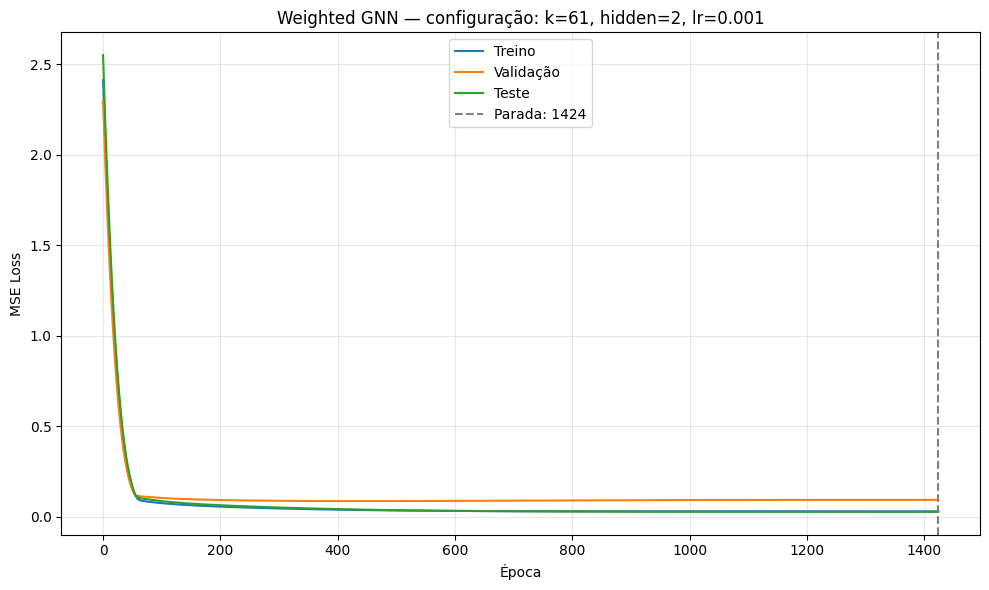

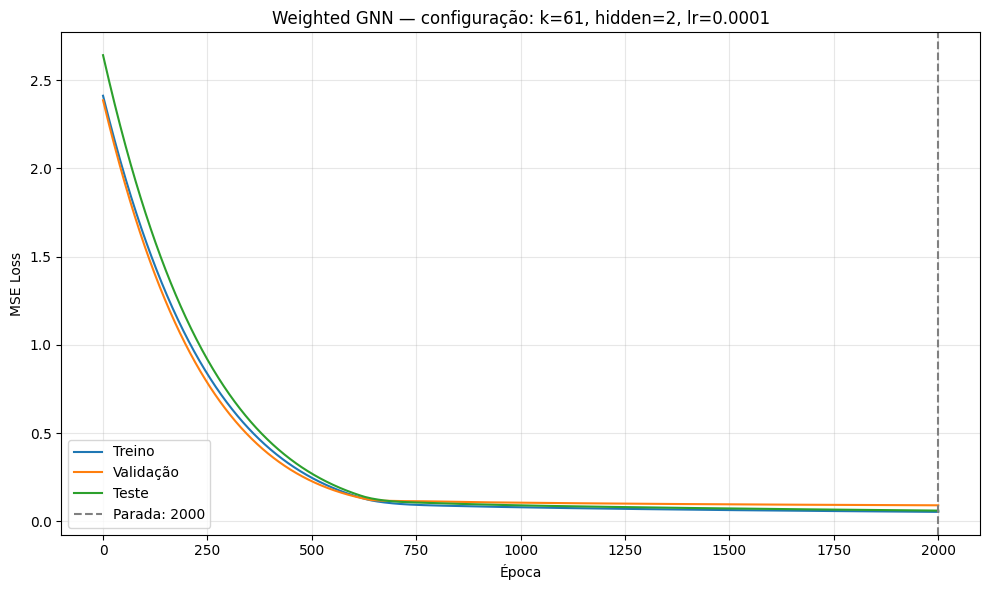

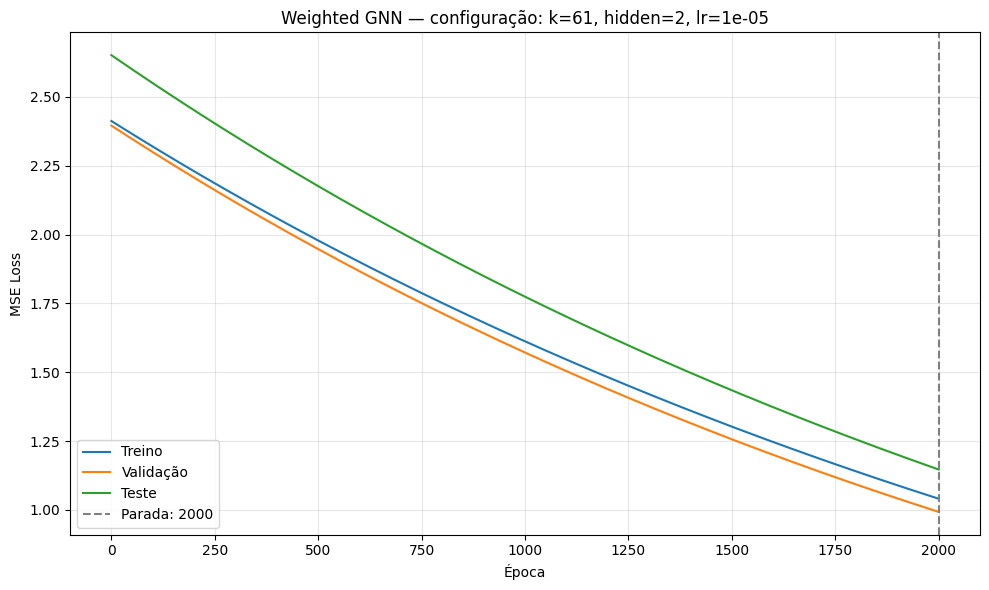

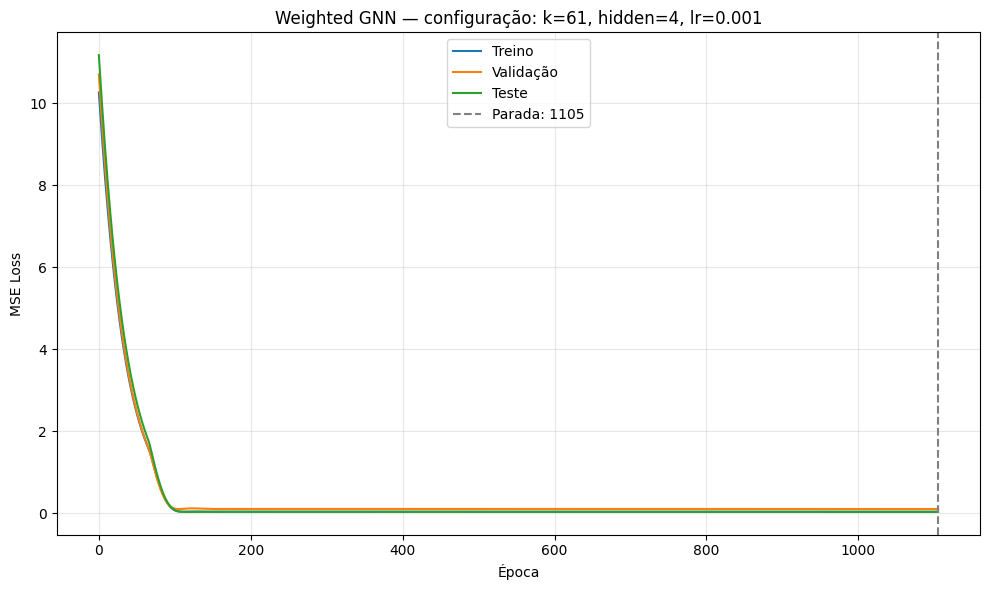

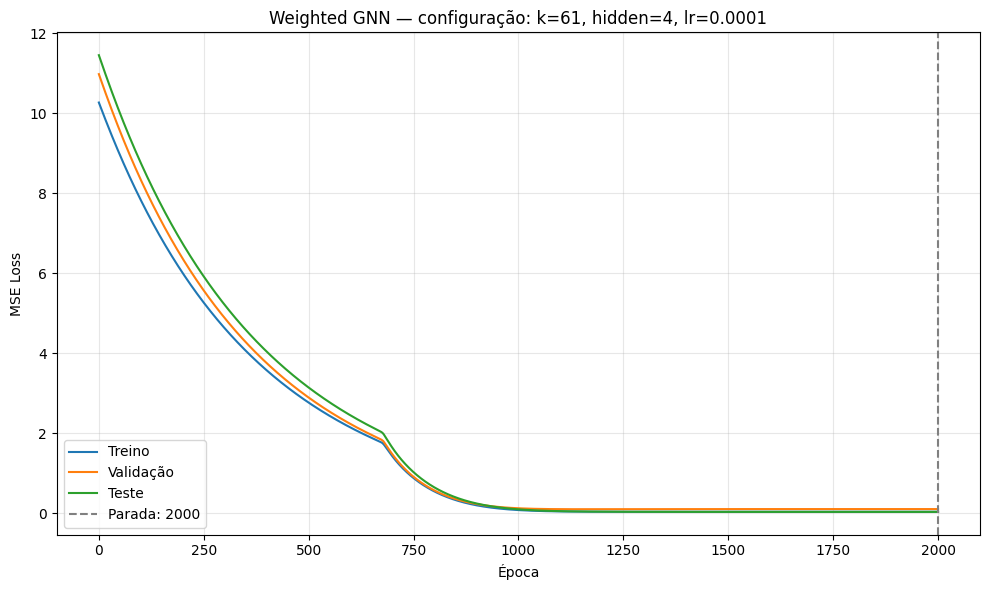

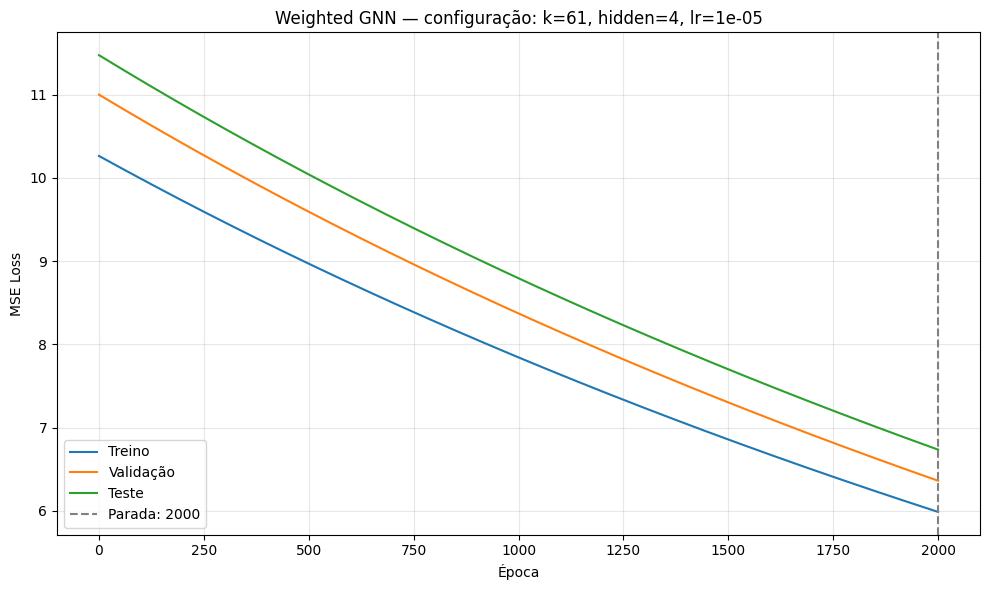

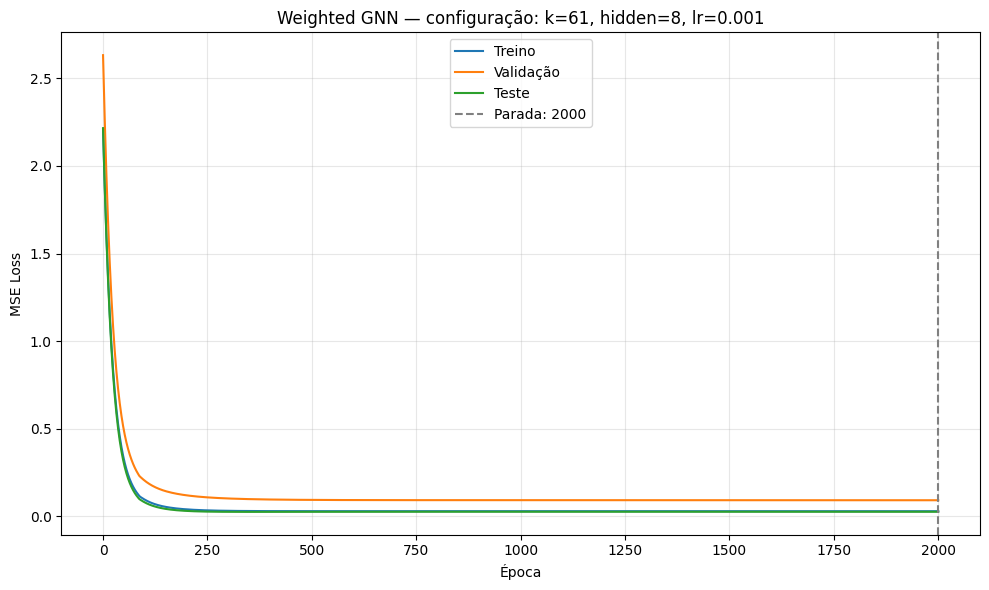

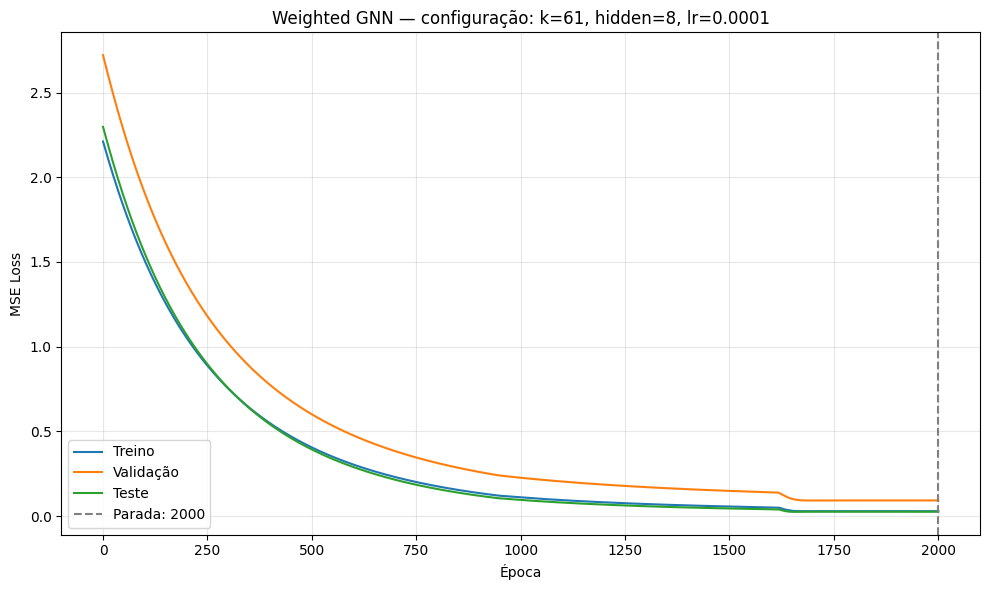

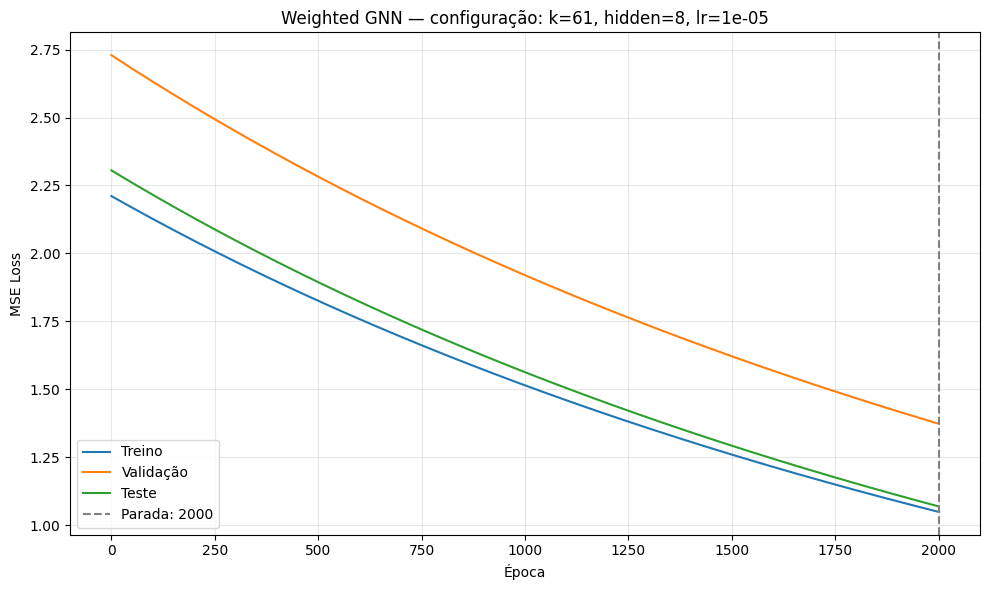

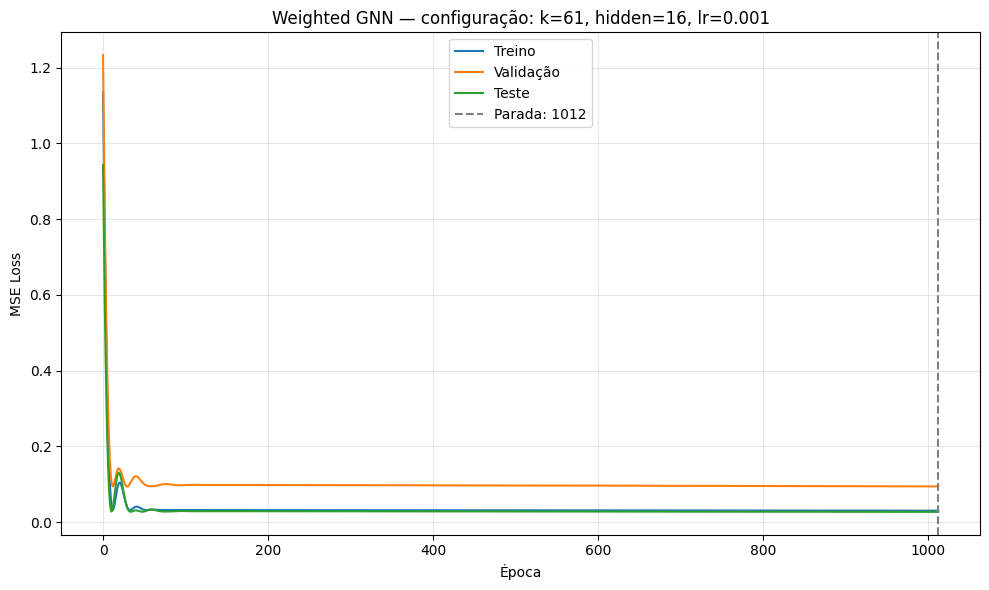

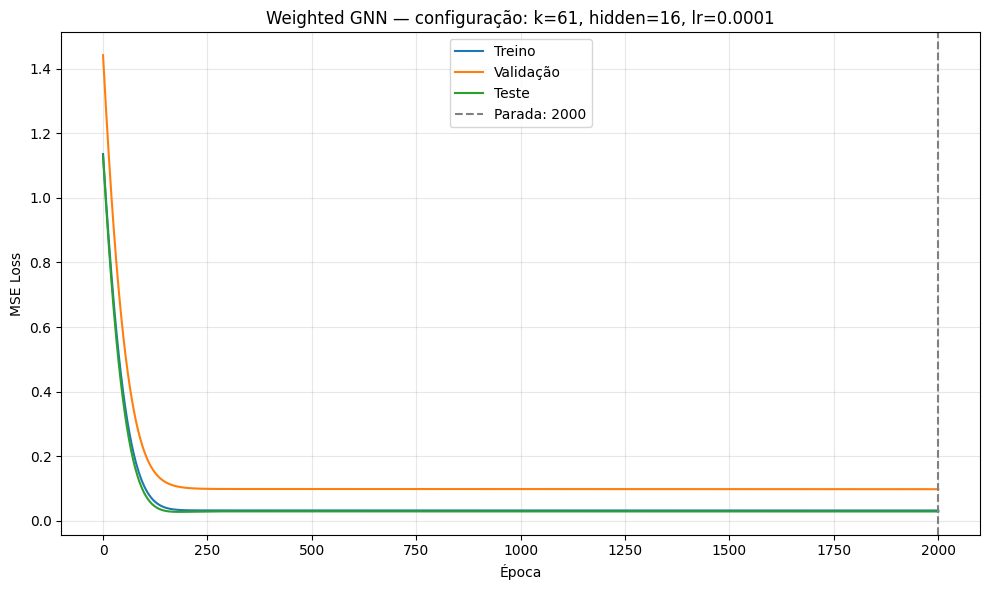

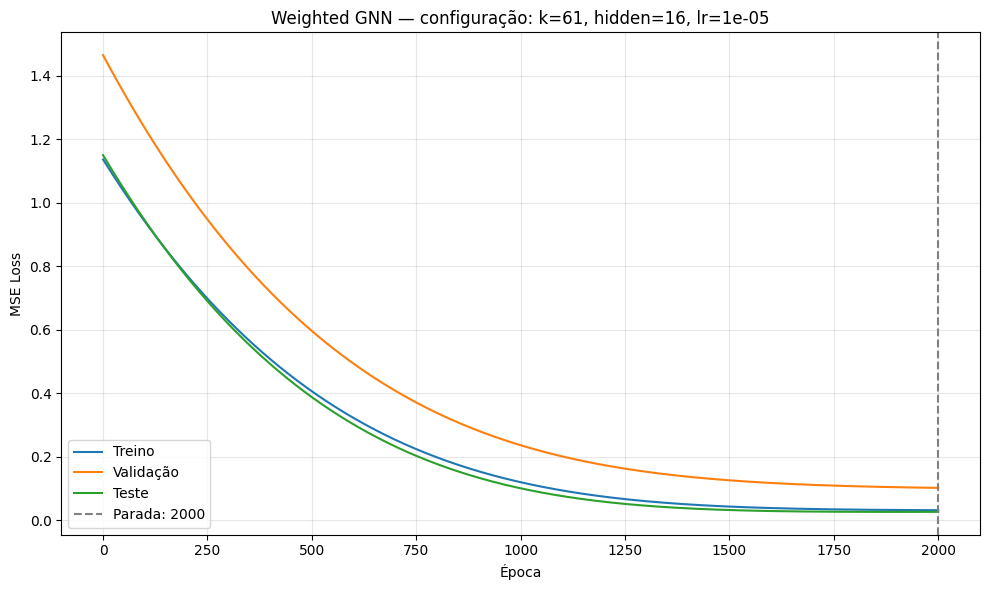

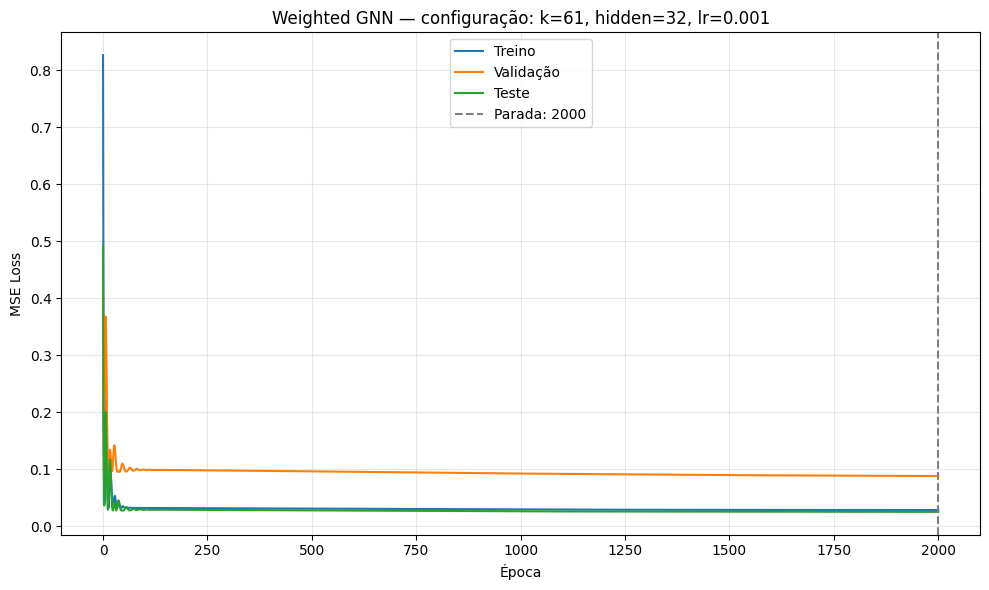

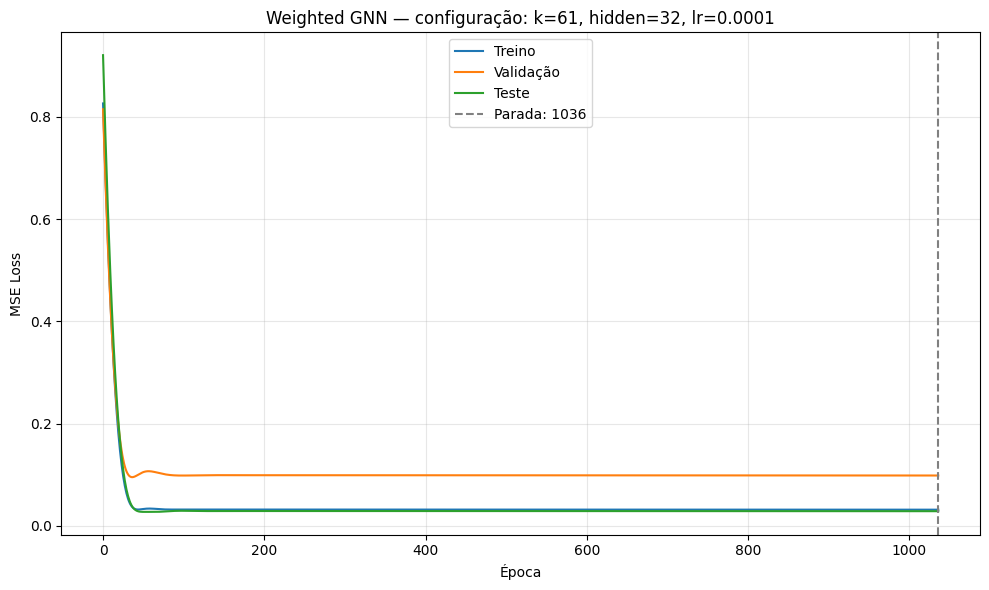

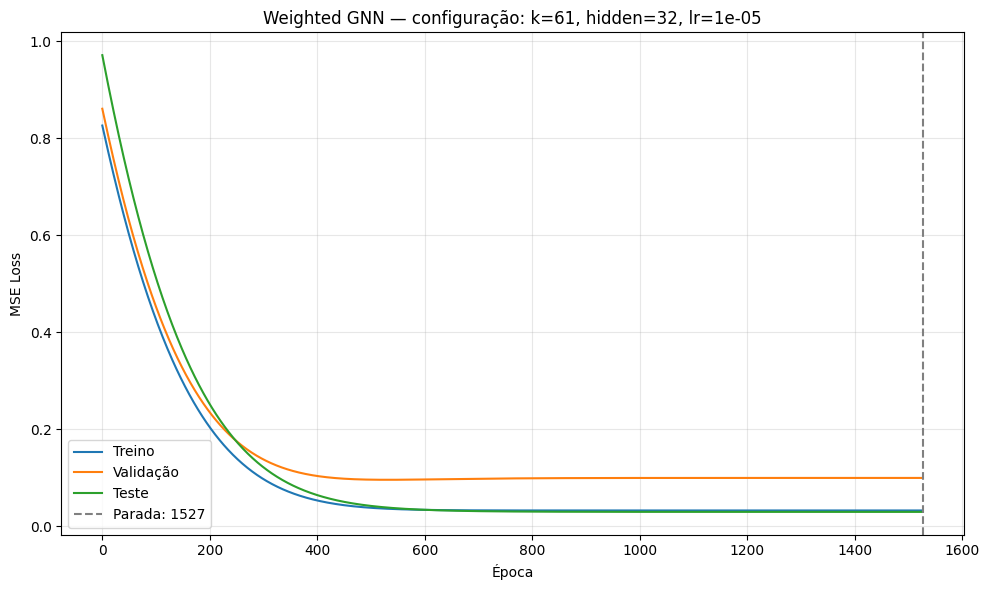

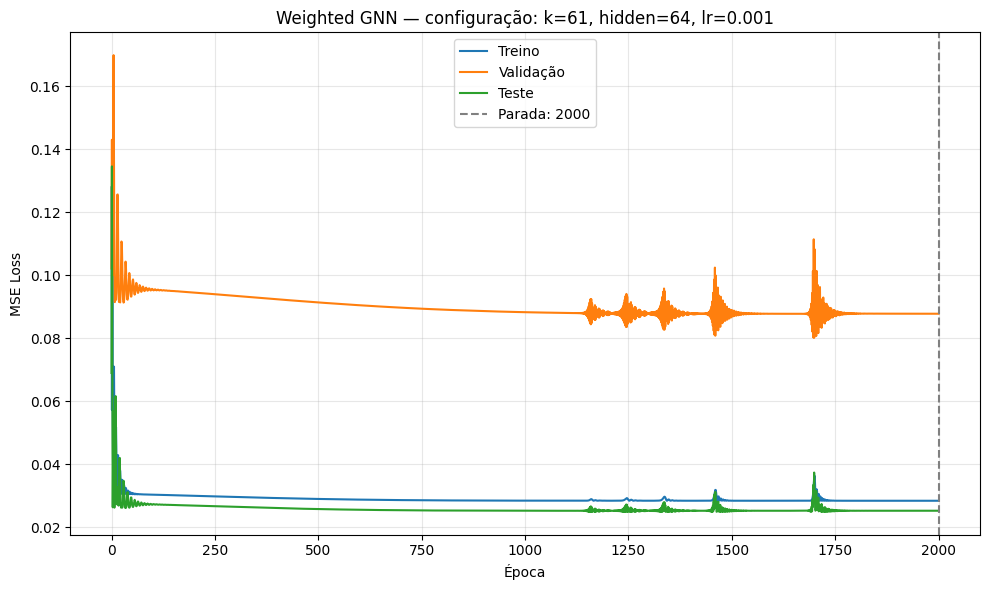

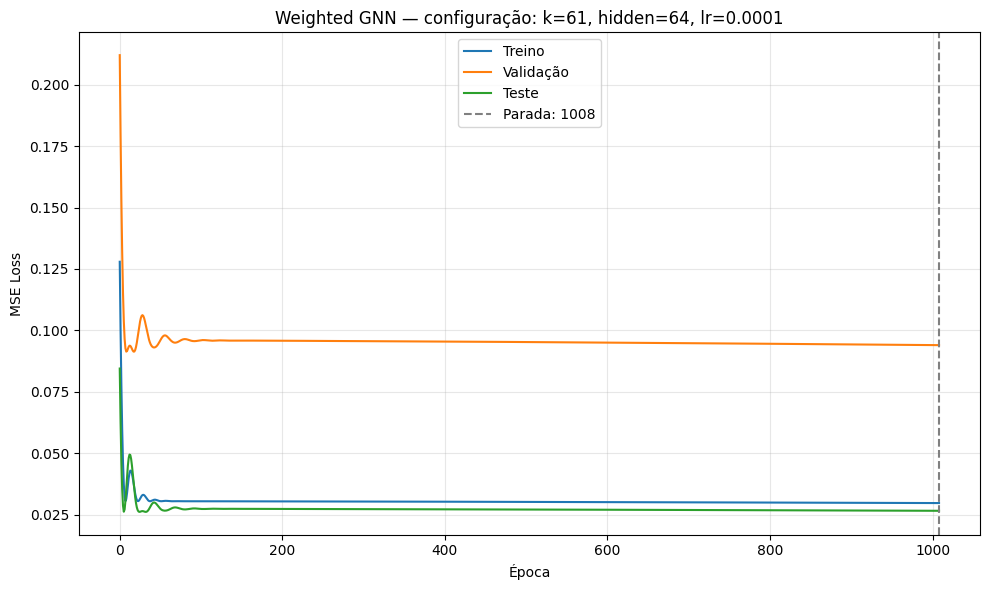

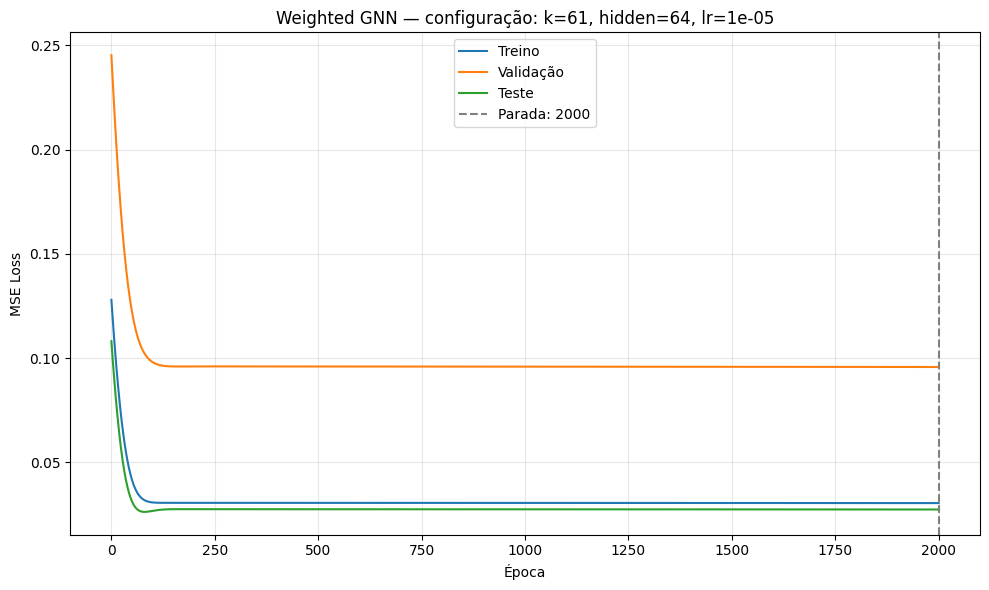

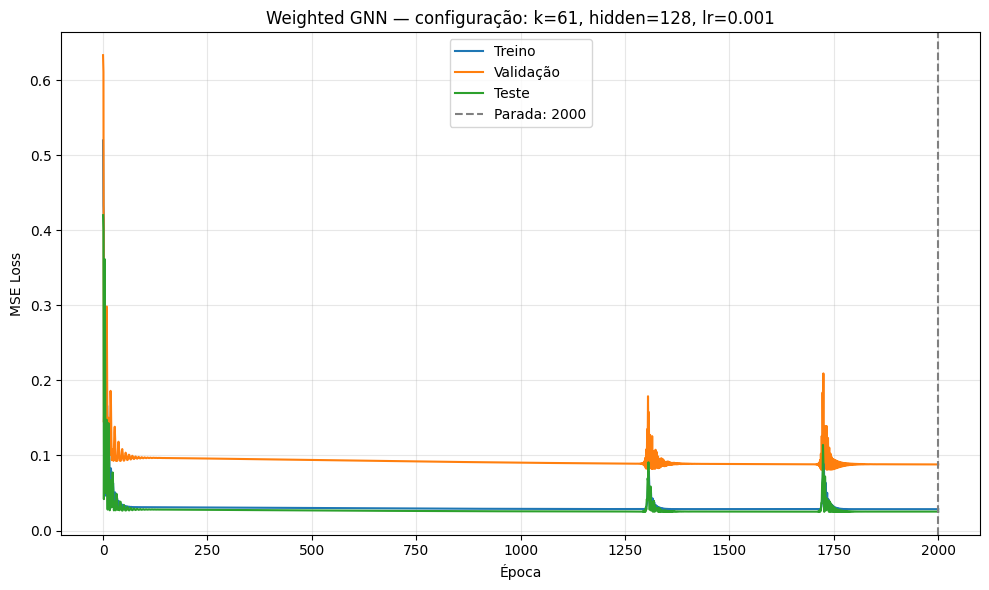

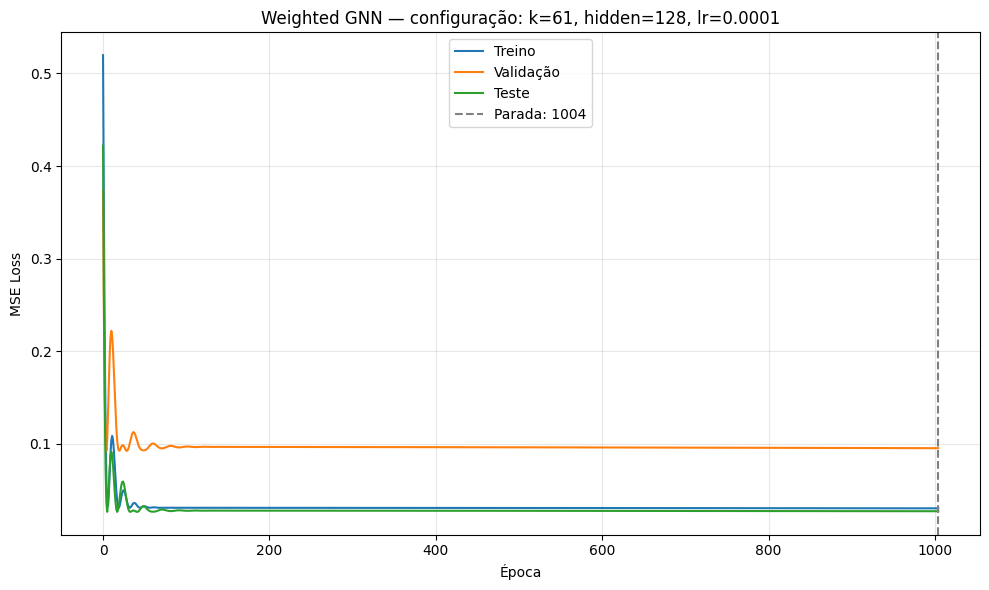

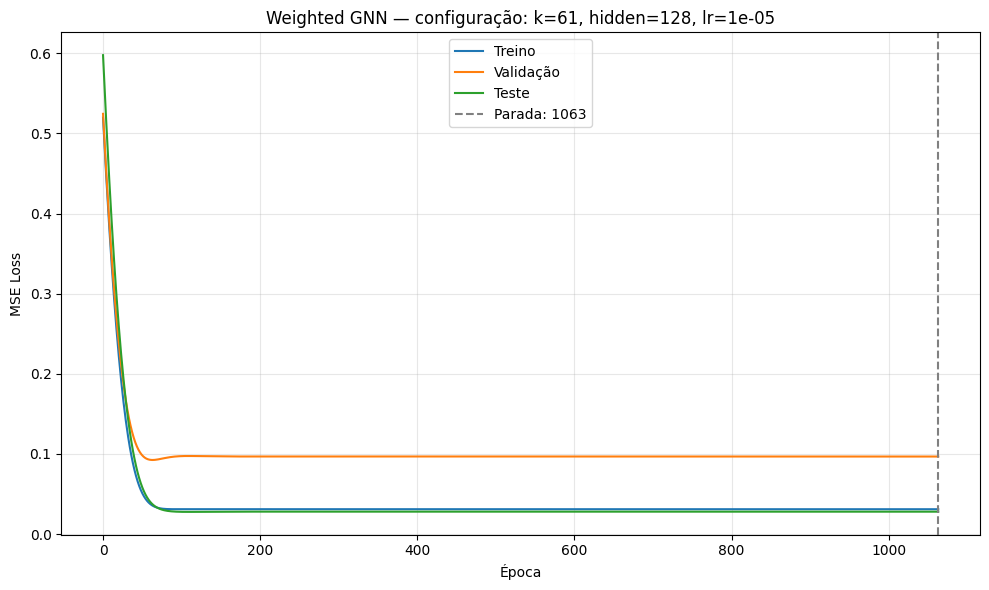

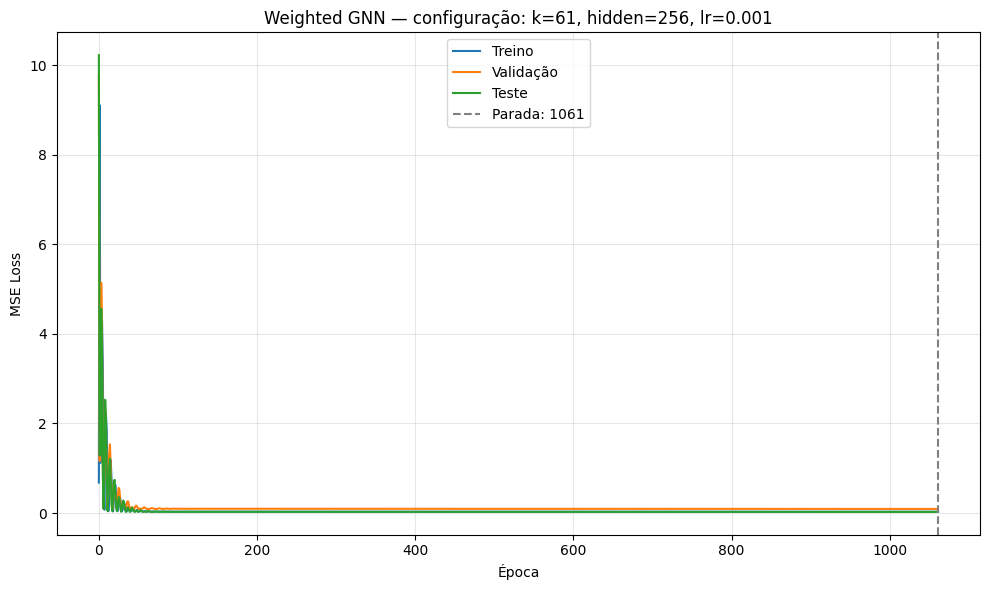

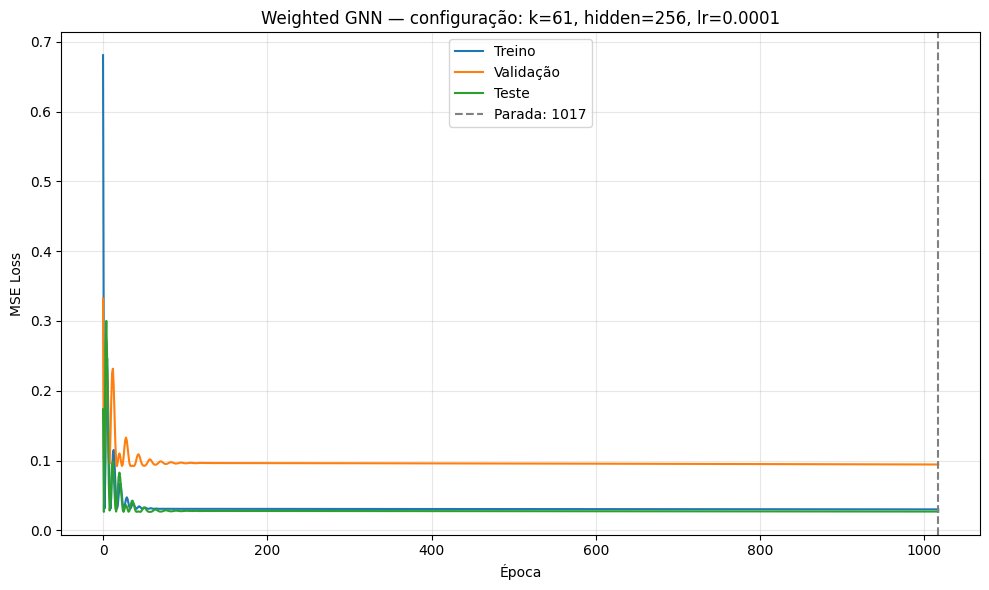

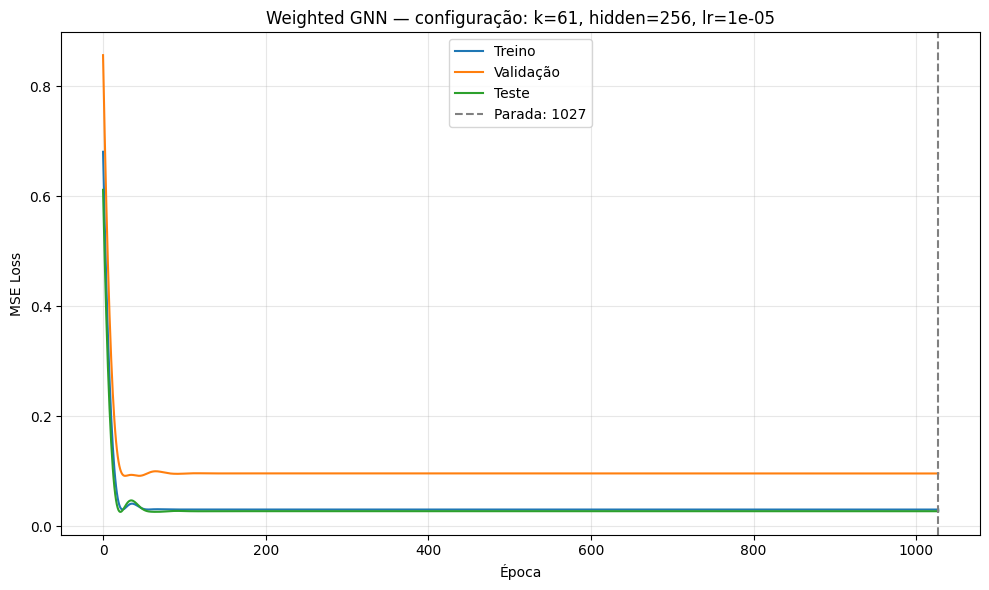

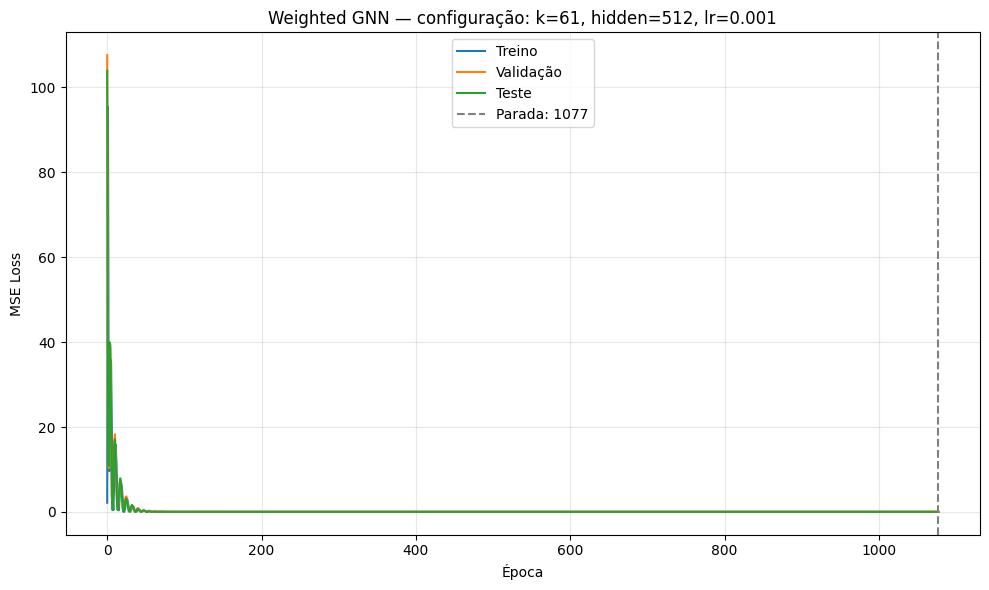

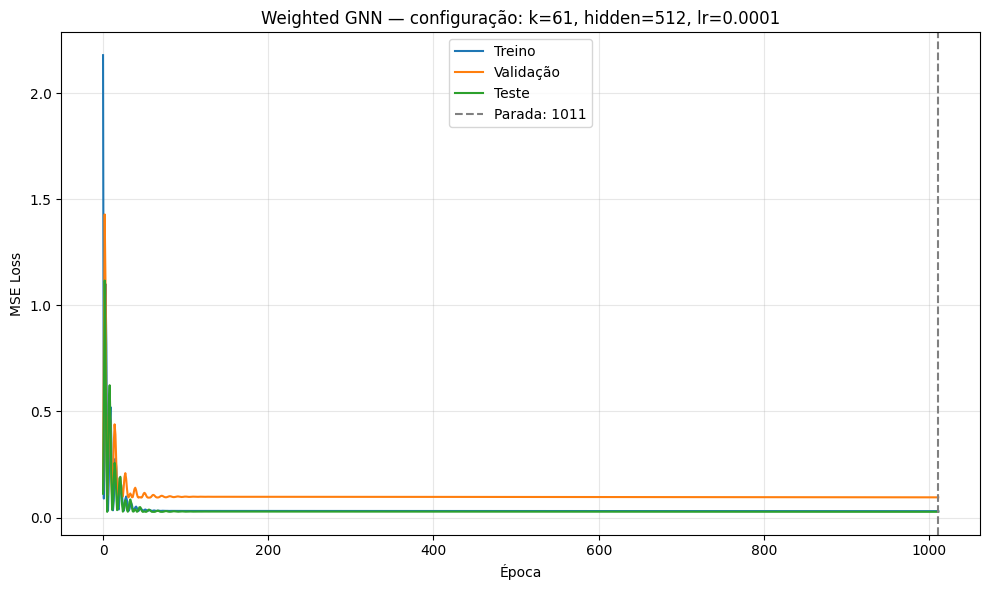

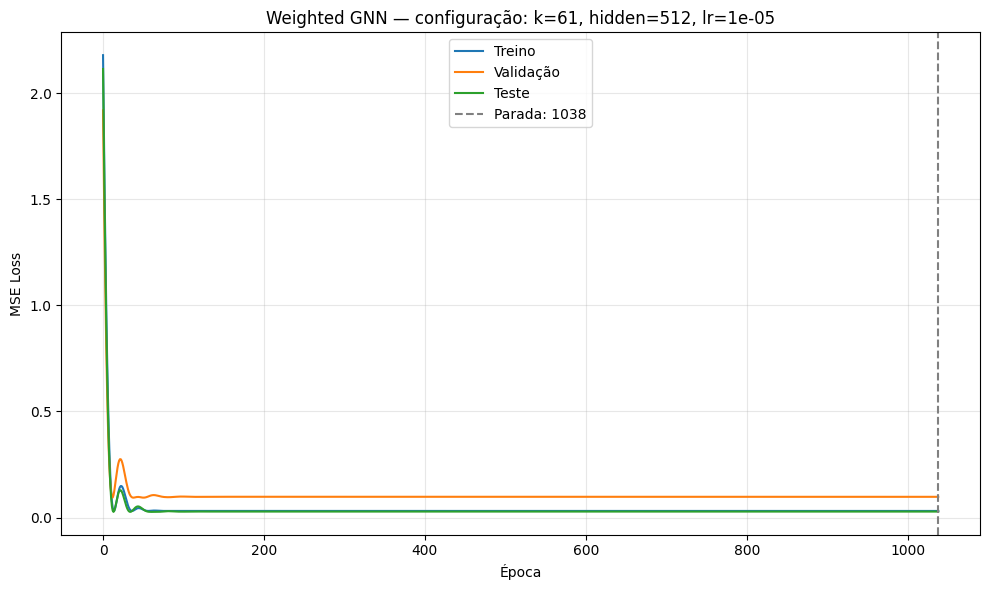

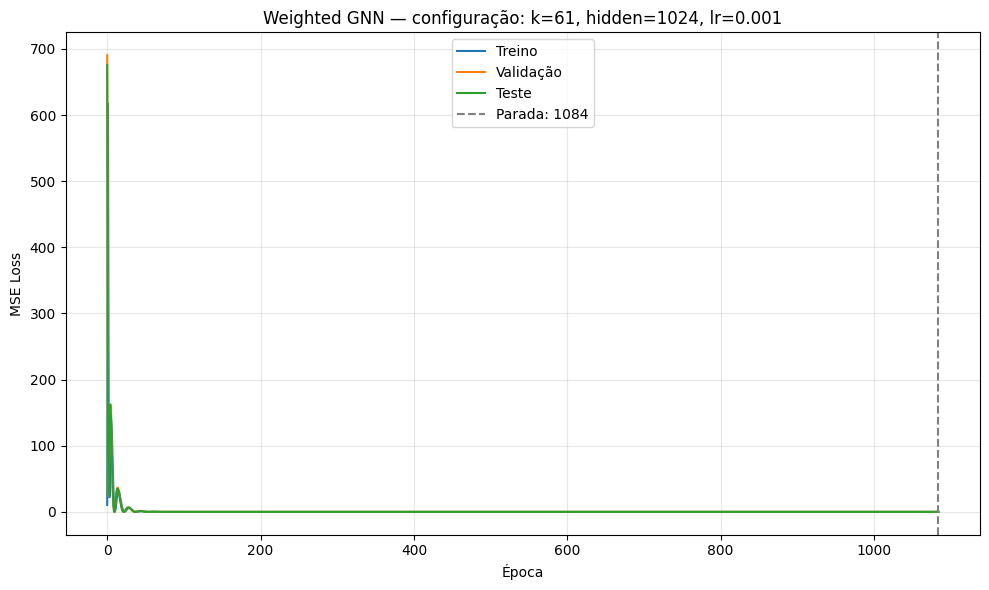

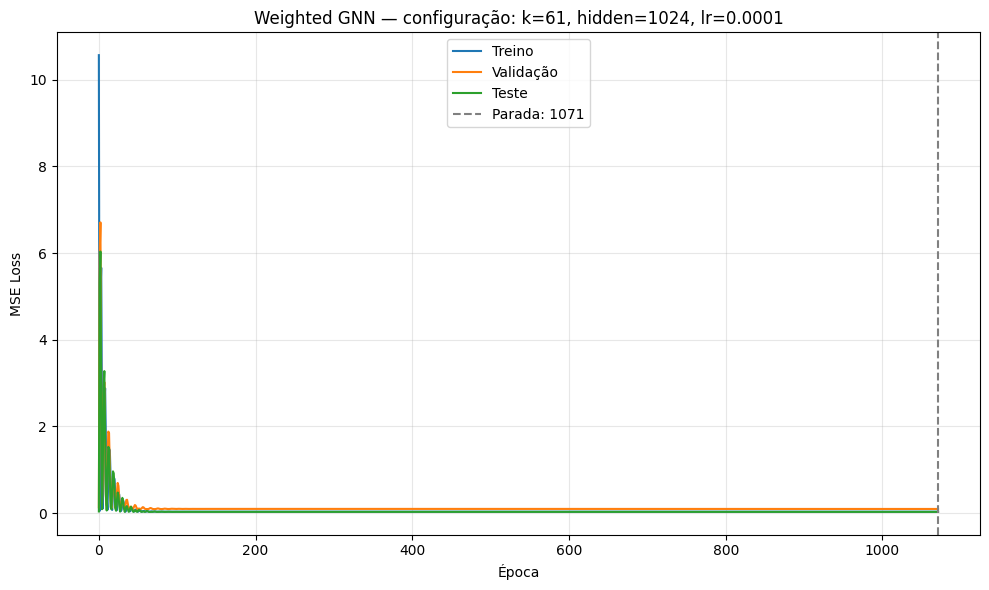

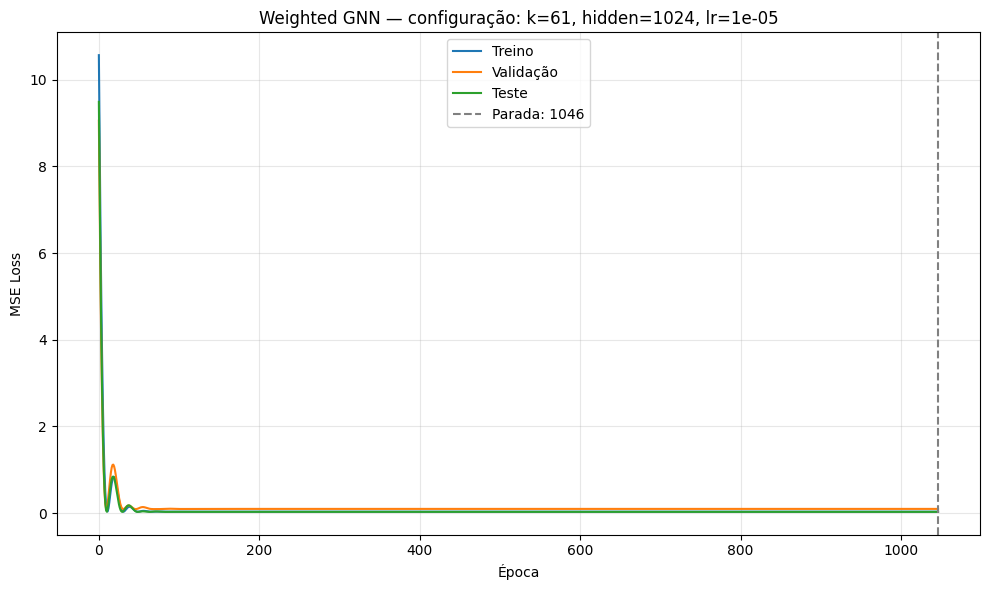

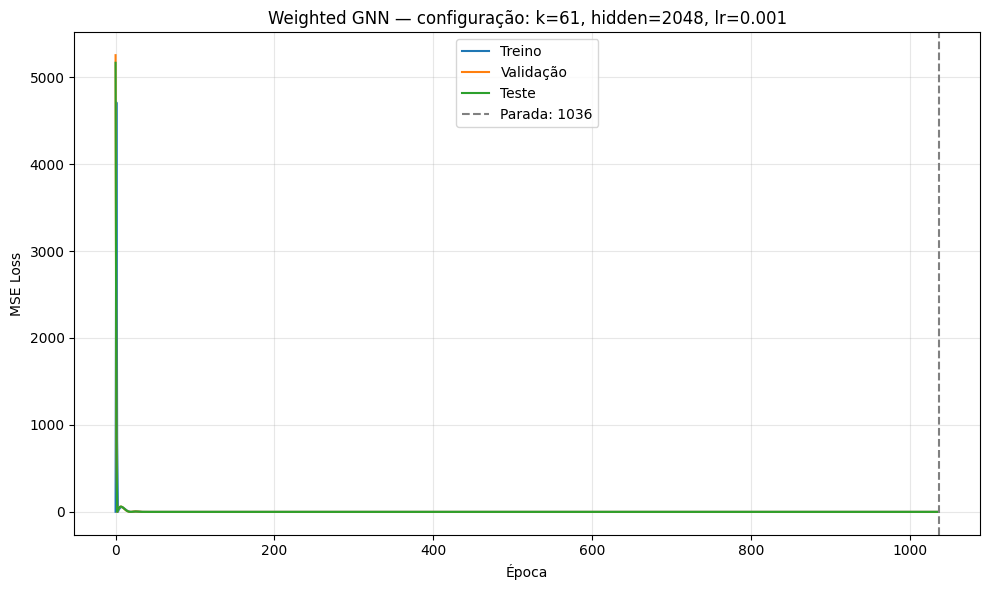

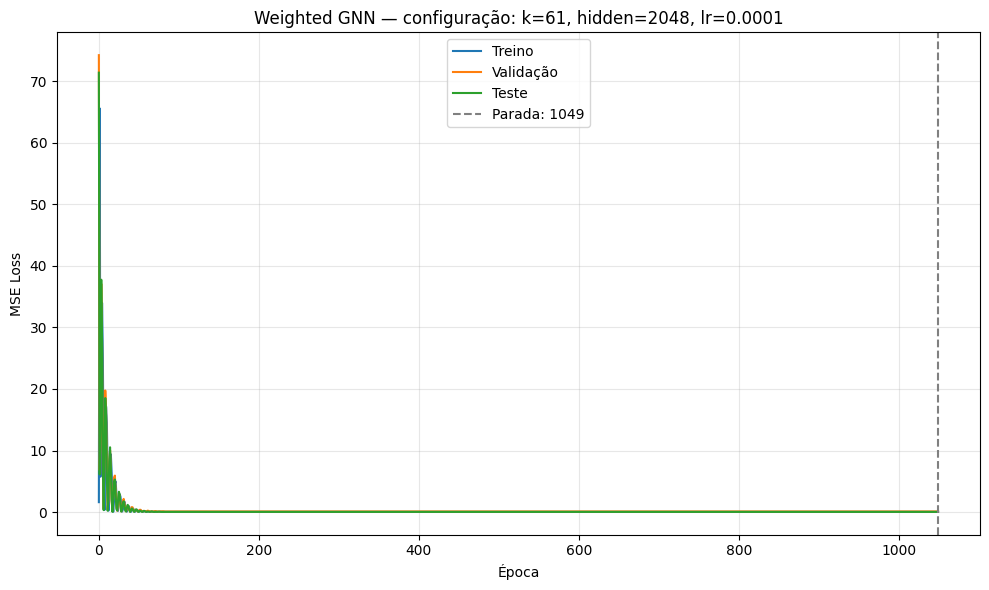

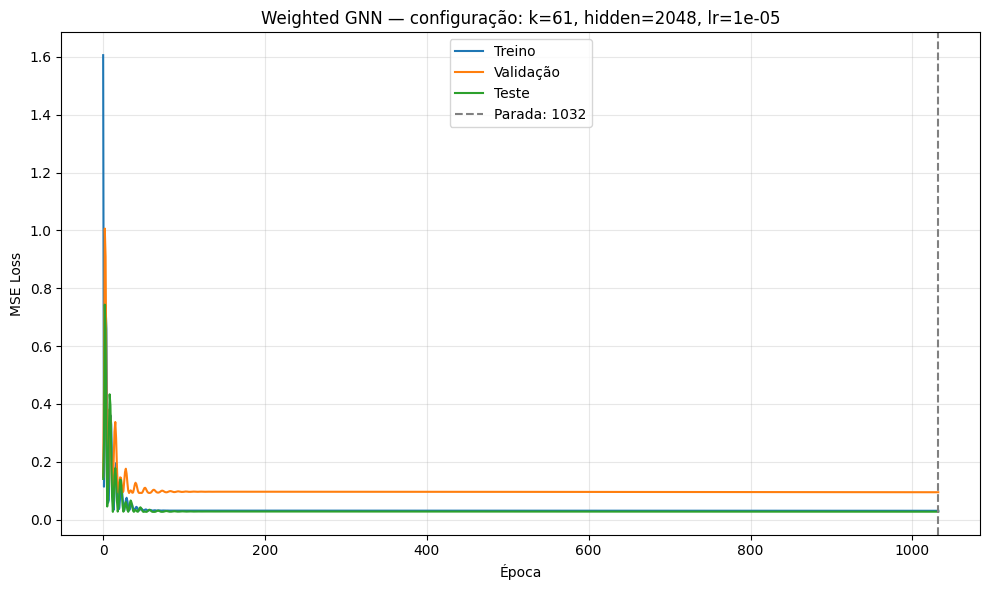

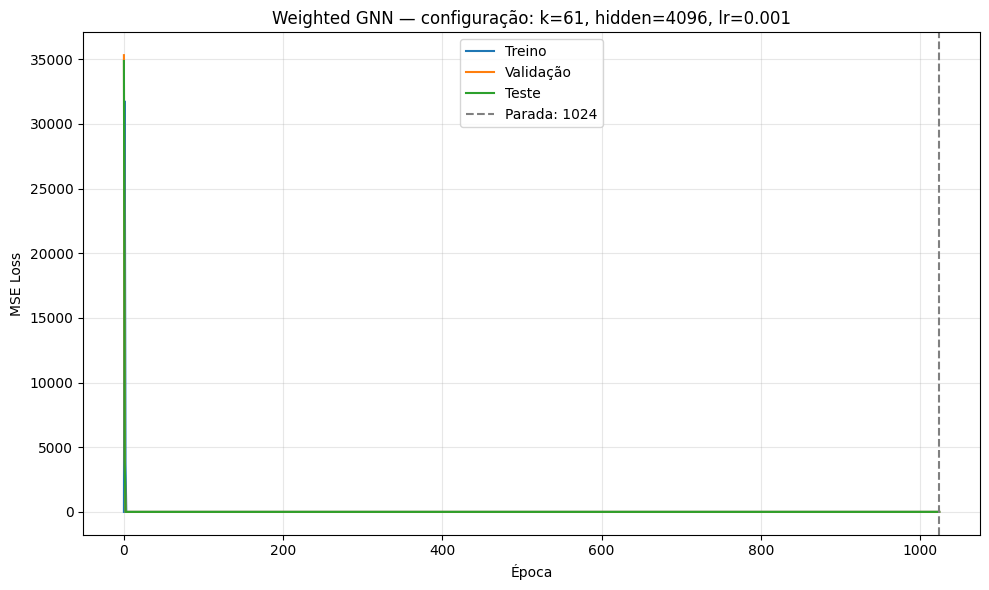

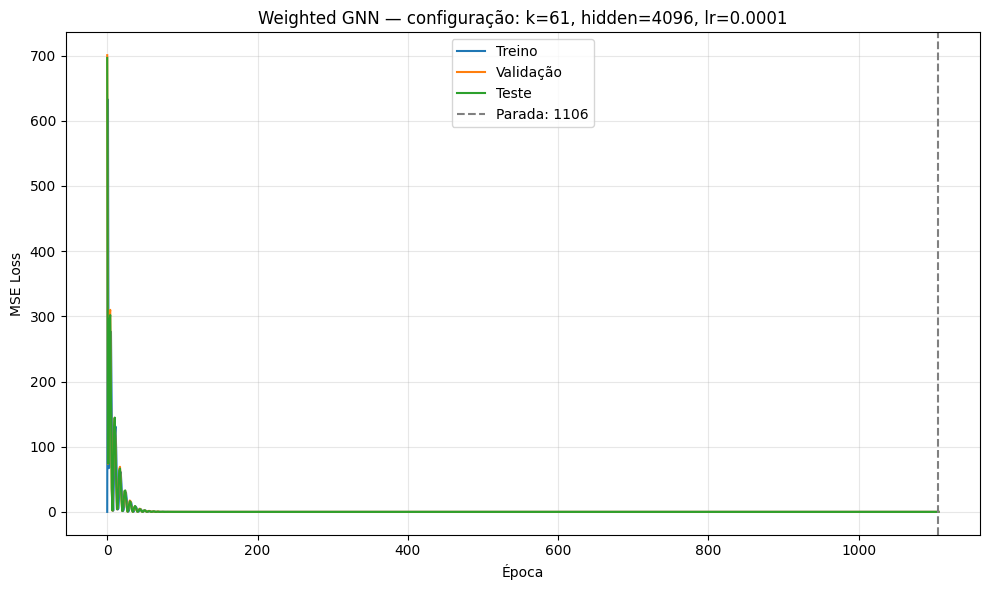

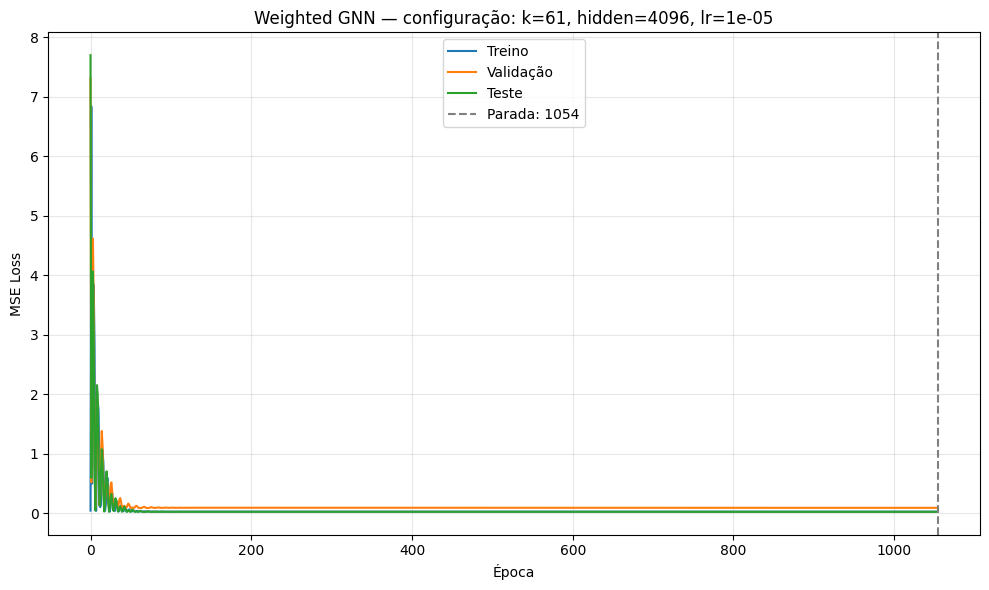

In [22]:
stop_epochs = {
    tuple(row[name] for name in grid_names): row["stop_epoch"]
    for row in grid_rows
}

for config_key, history_run in grid_histories.items():
    config = dict(zip(grid_names, config_key))
    stop_epoch = stop_epochs[config_key]
    epochs_executed = range(len(history_run["train"]))

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(epochs_executed, history_run["train"], label="Treino")
    ax.plot(epochs_executed, history_run["validation"], label="Validação")
    ax.plot(epochs_executed, history_run["test"], label="Teste")
    ax.axvline(
        stop_epoch,
        color="gray",
        linestyle="--",
        label=f"Parada: {stop_epoch}",
    )

    ax.set(
        title=(
            "Weighted GNN — configuração: "
            f"k={config['k']}, hidden={config['hidden_dim']}, "
            f"lr={config['learning_rate']}"
        ),
        xlabel="Época",
        ylabel="MSE Loss",
    )
    ax.grid(alpha=0.3)
    ax.legend()
    fig.tight_layout()
    plt.show()

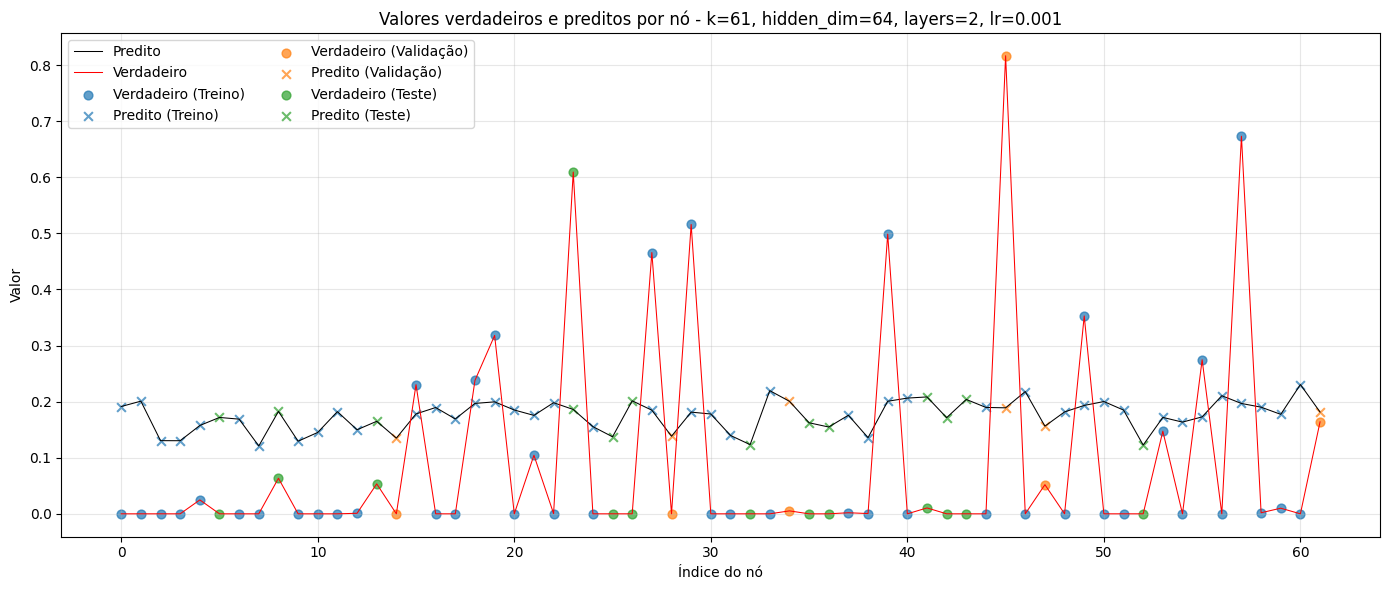

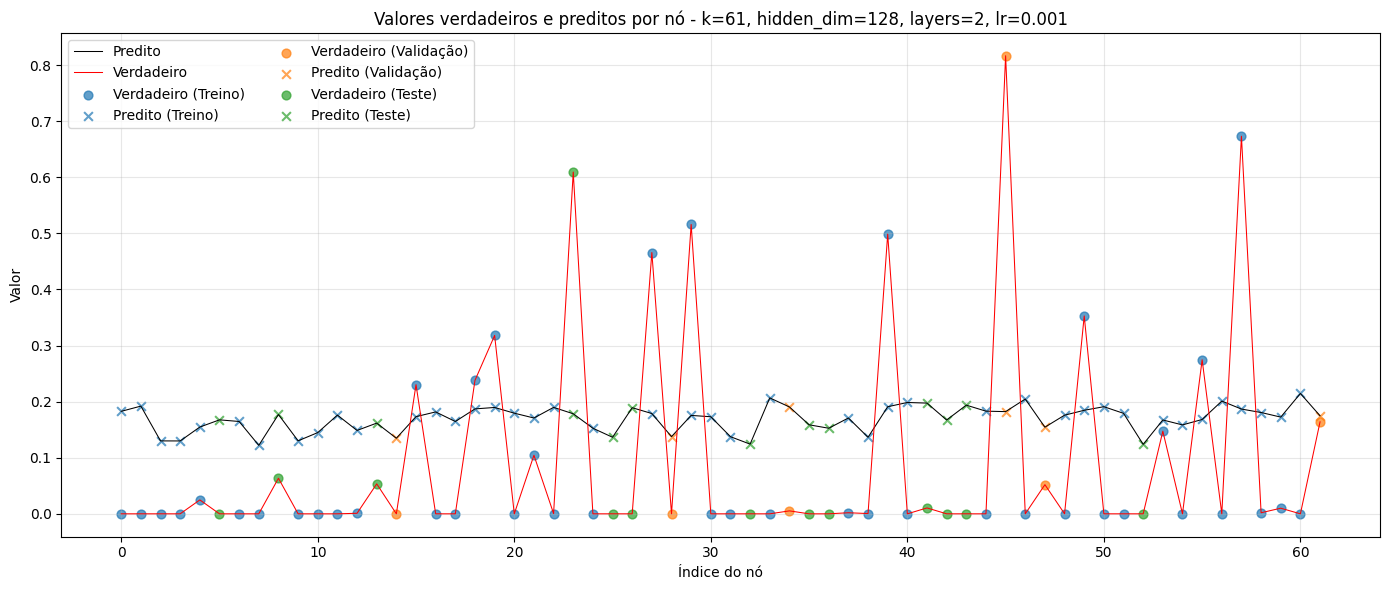

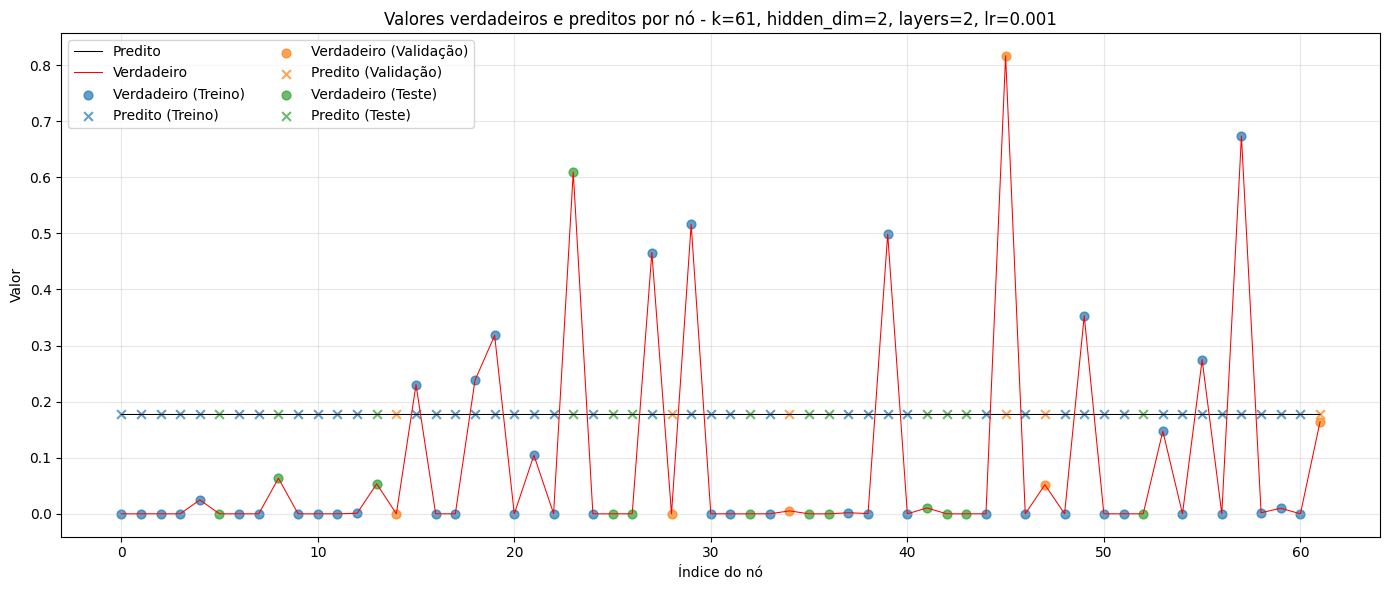

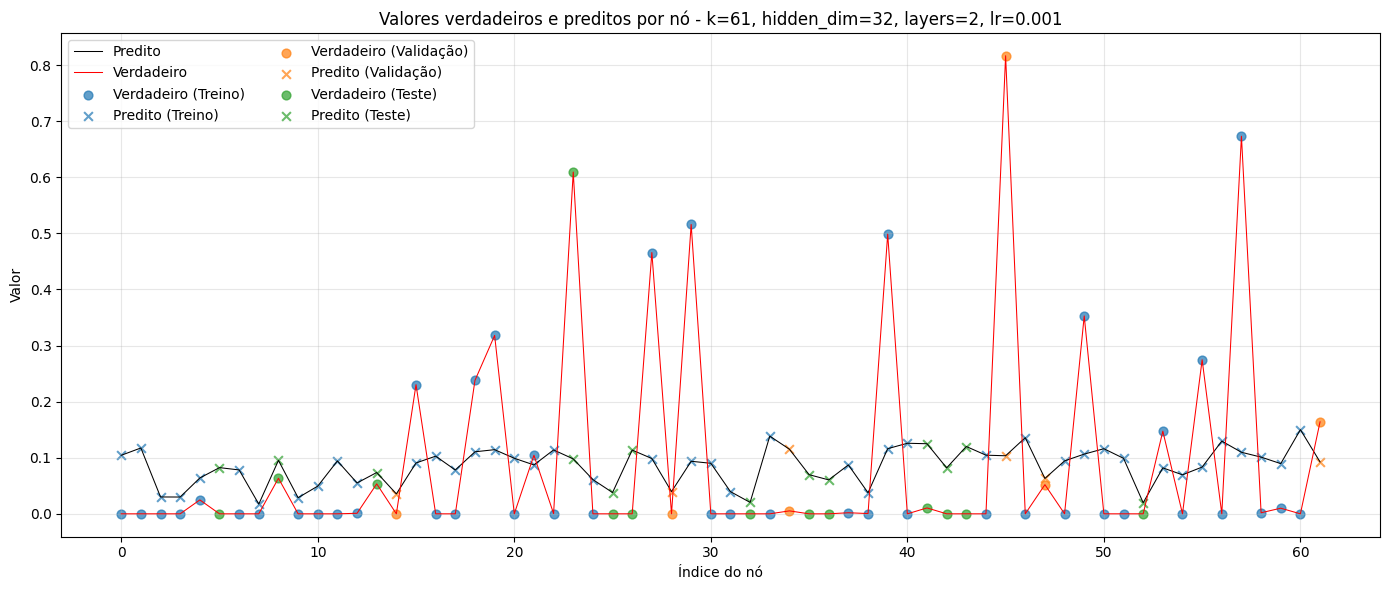

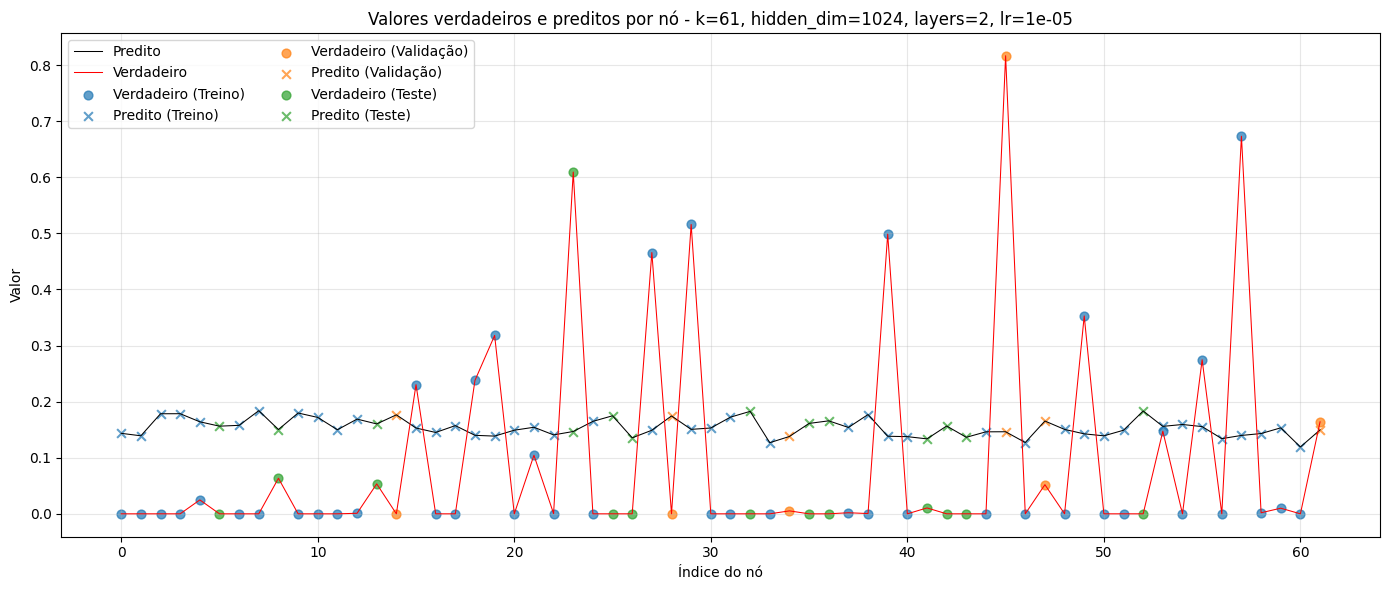

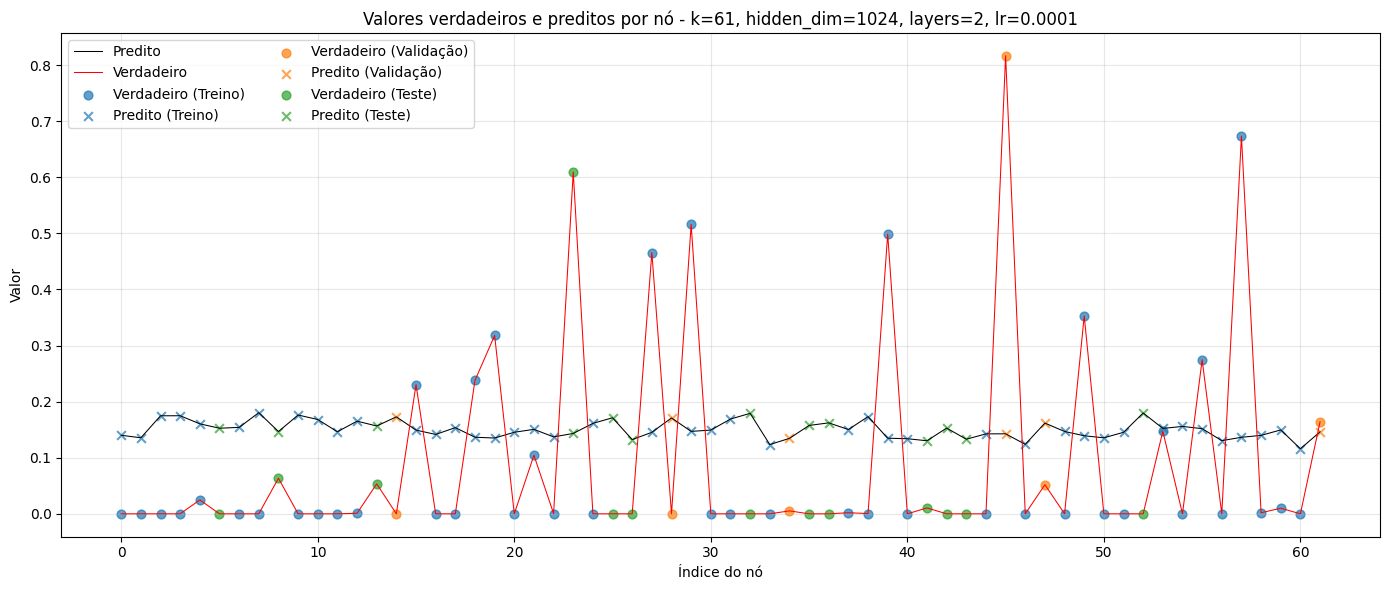

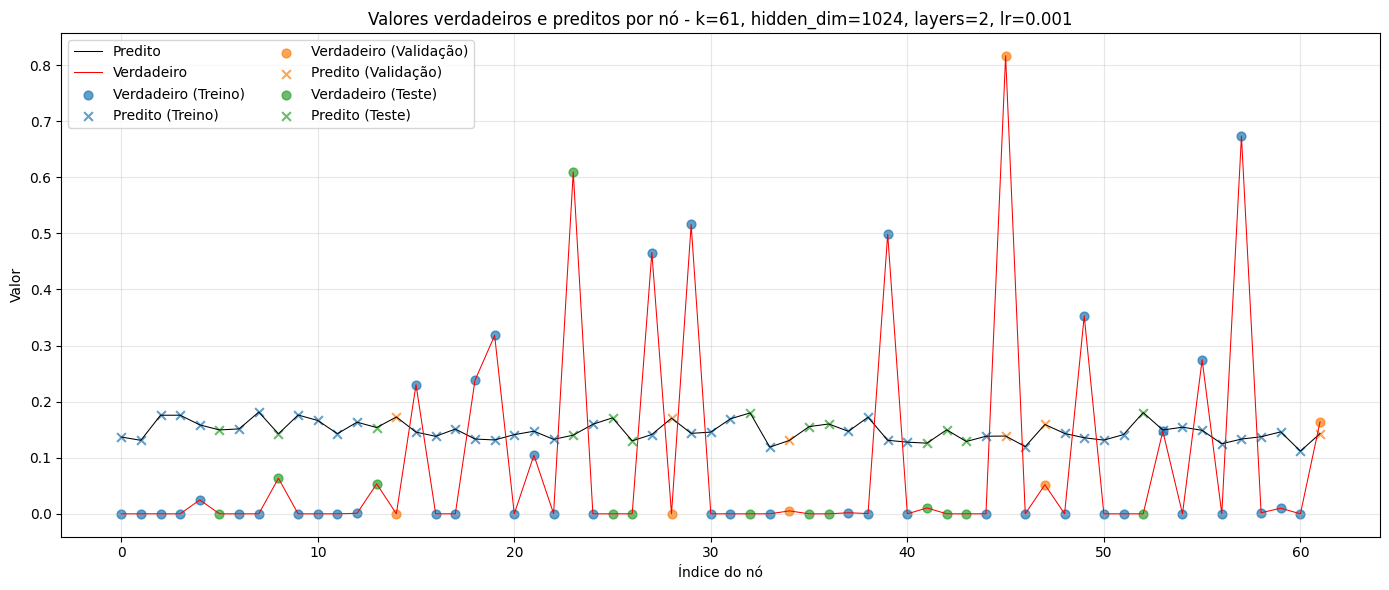

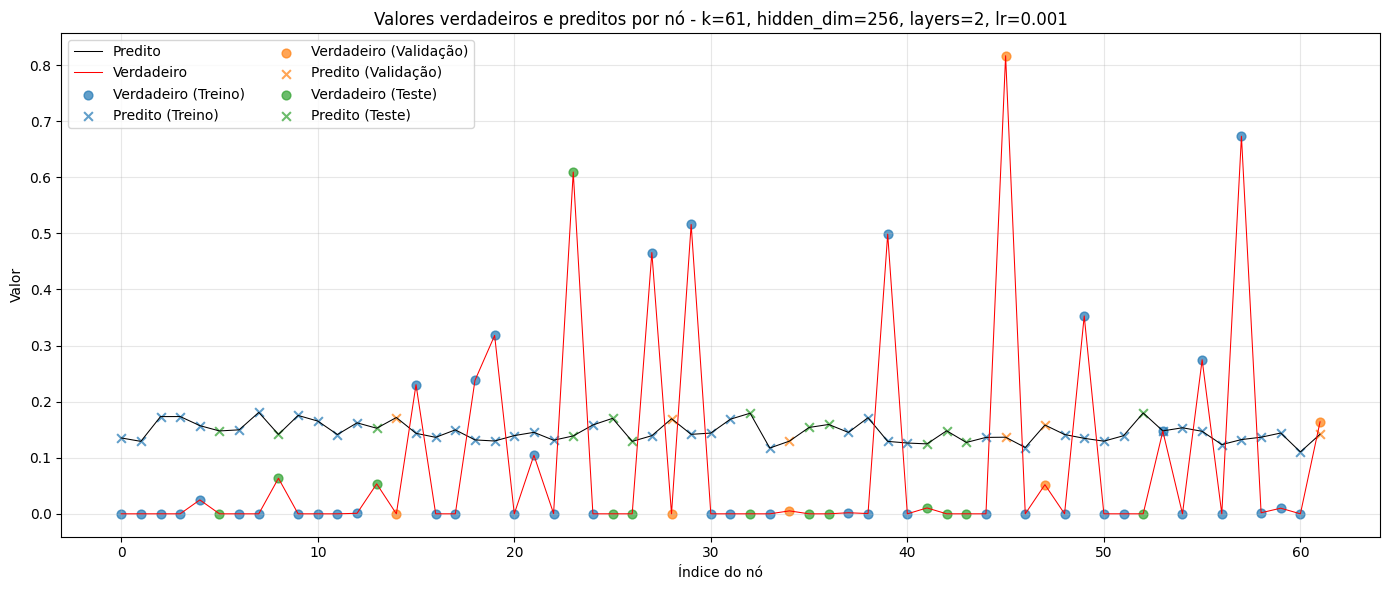

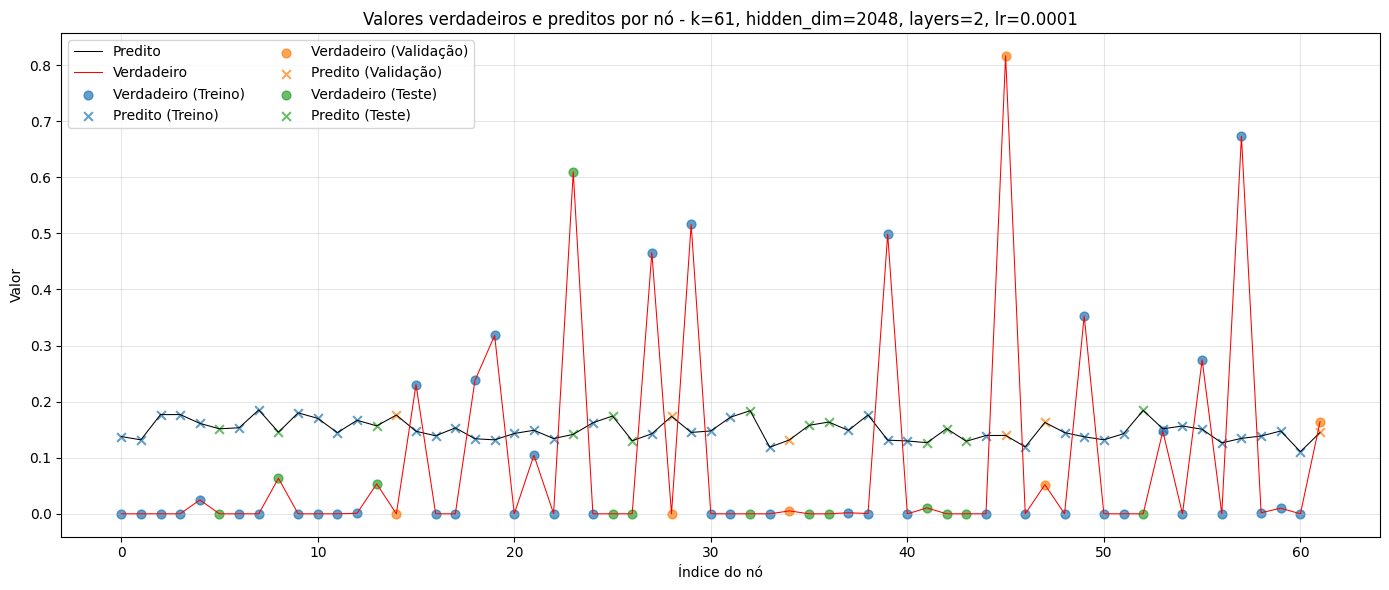

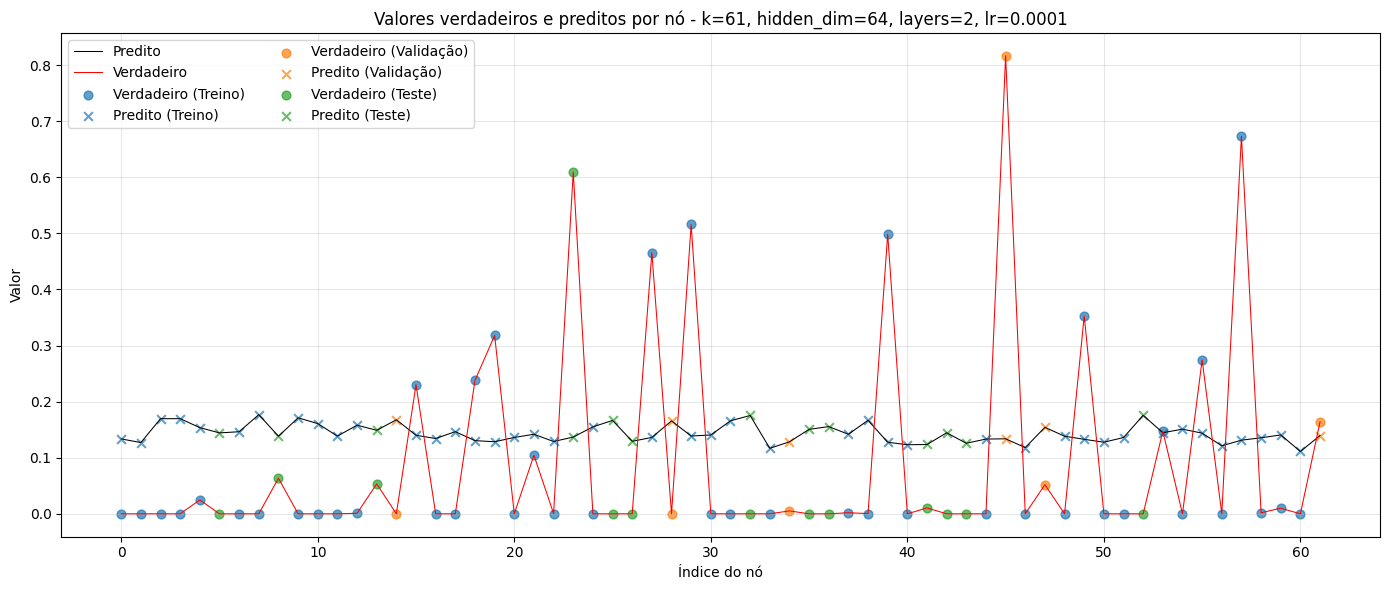

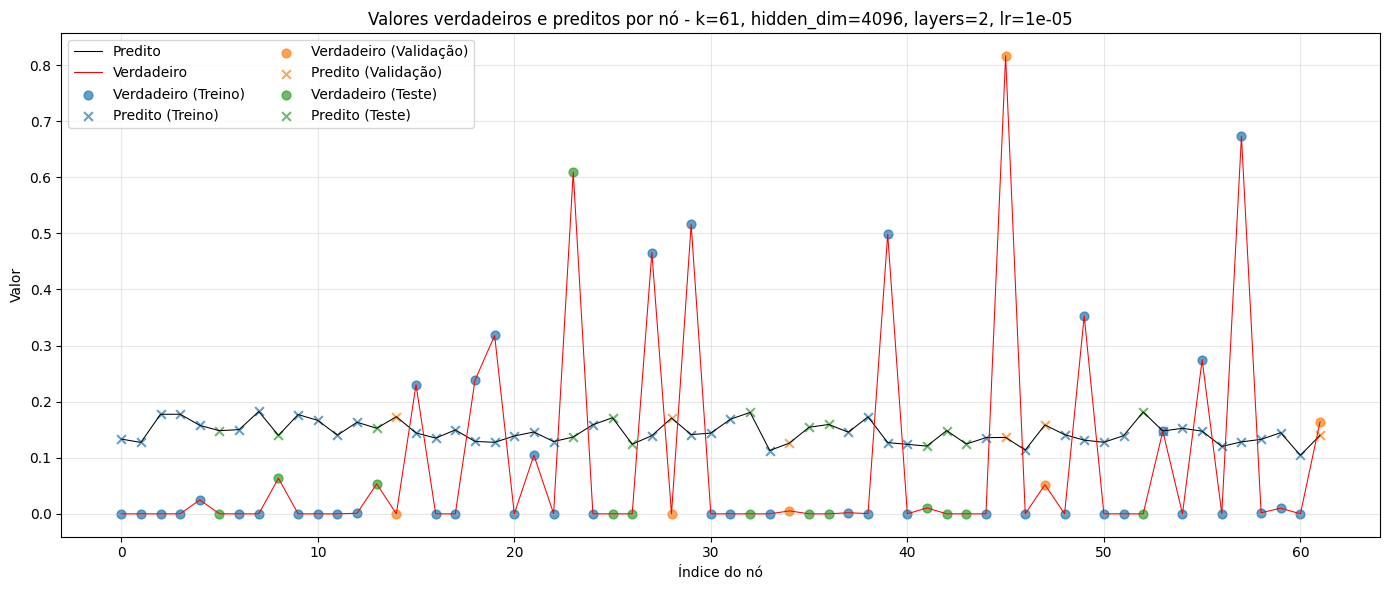

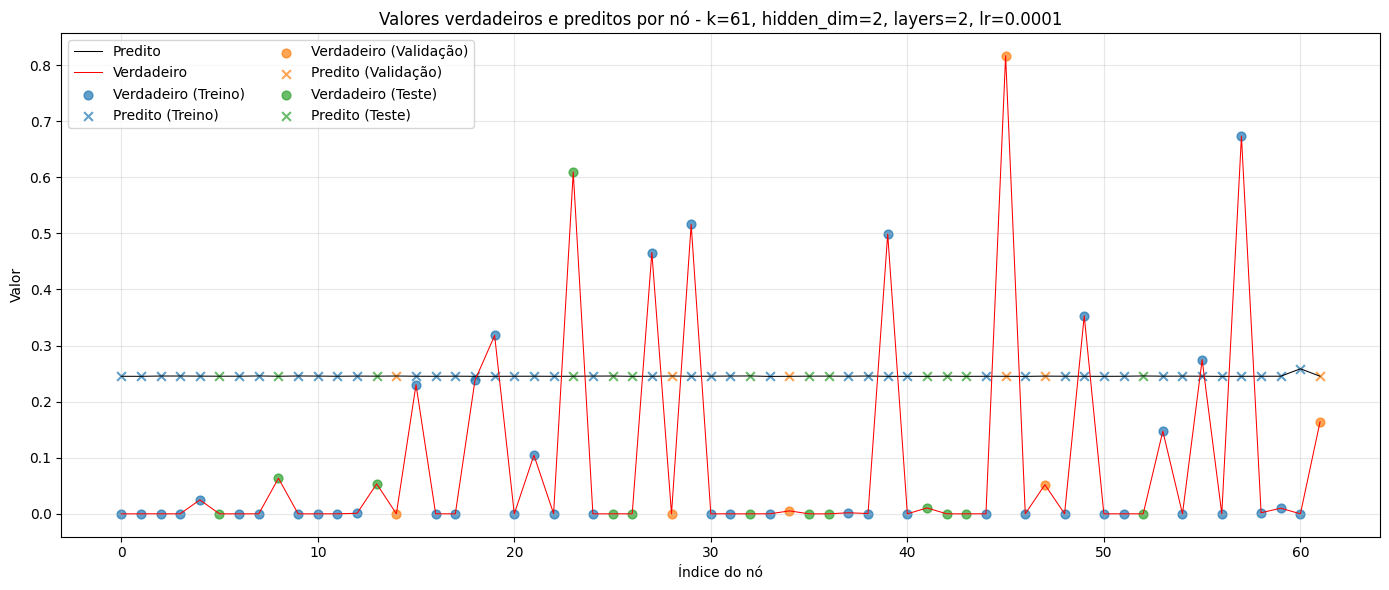

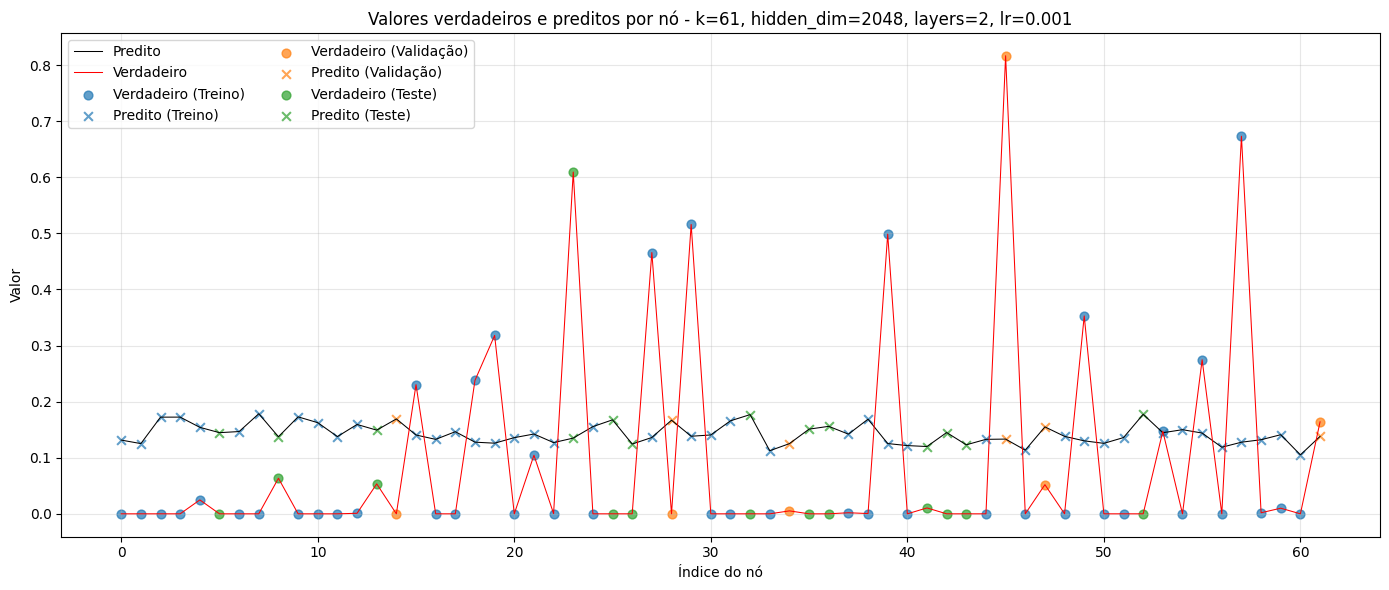

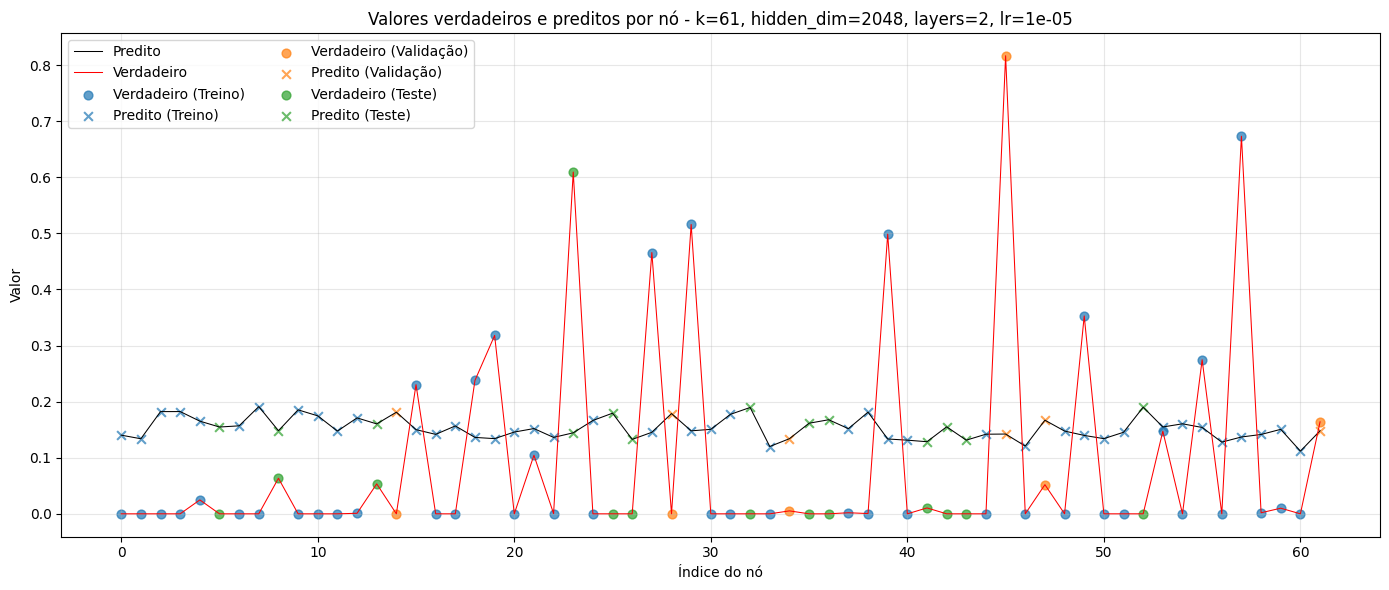

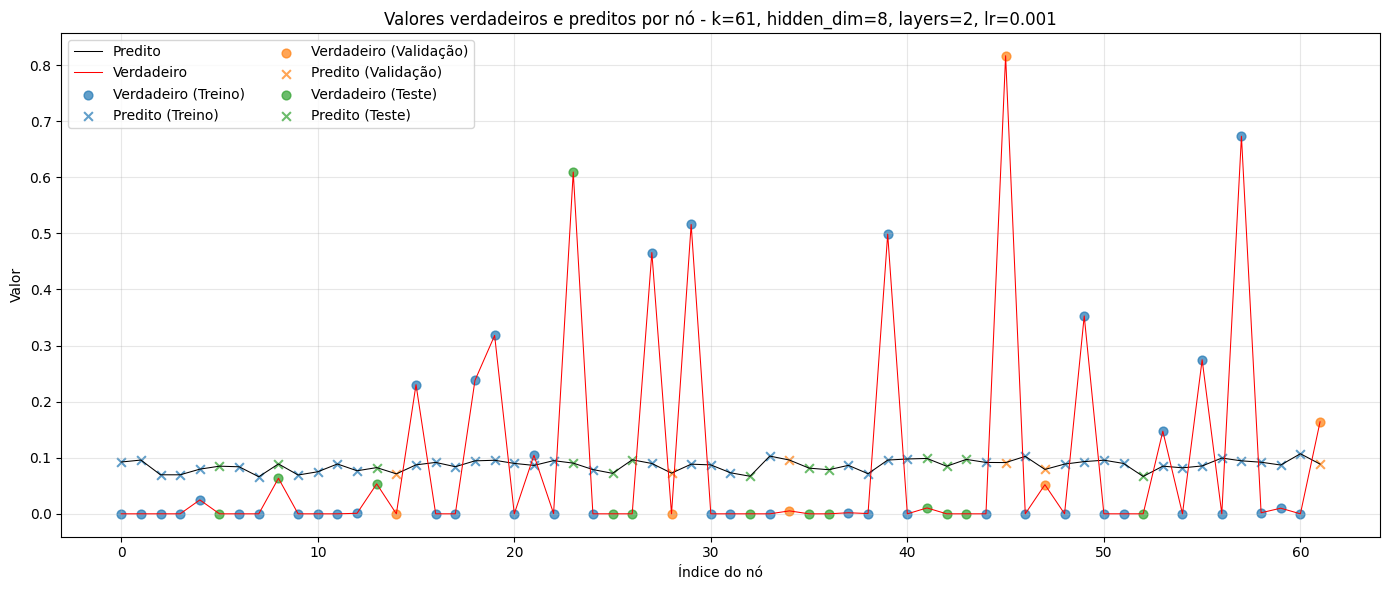

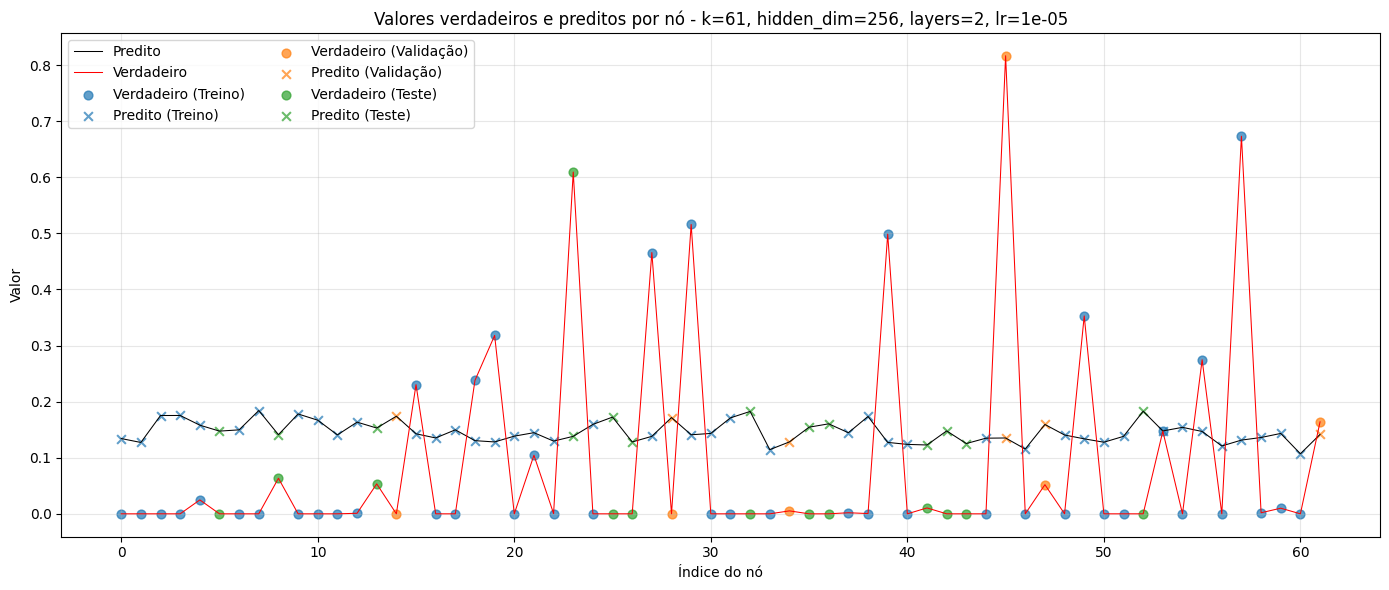

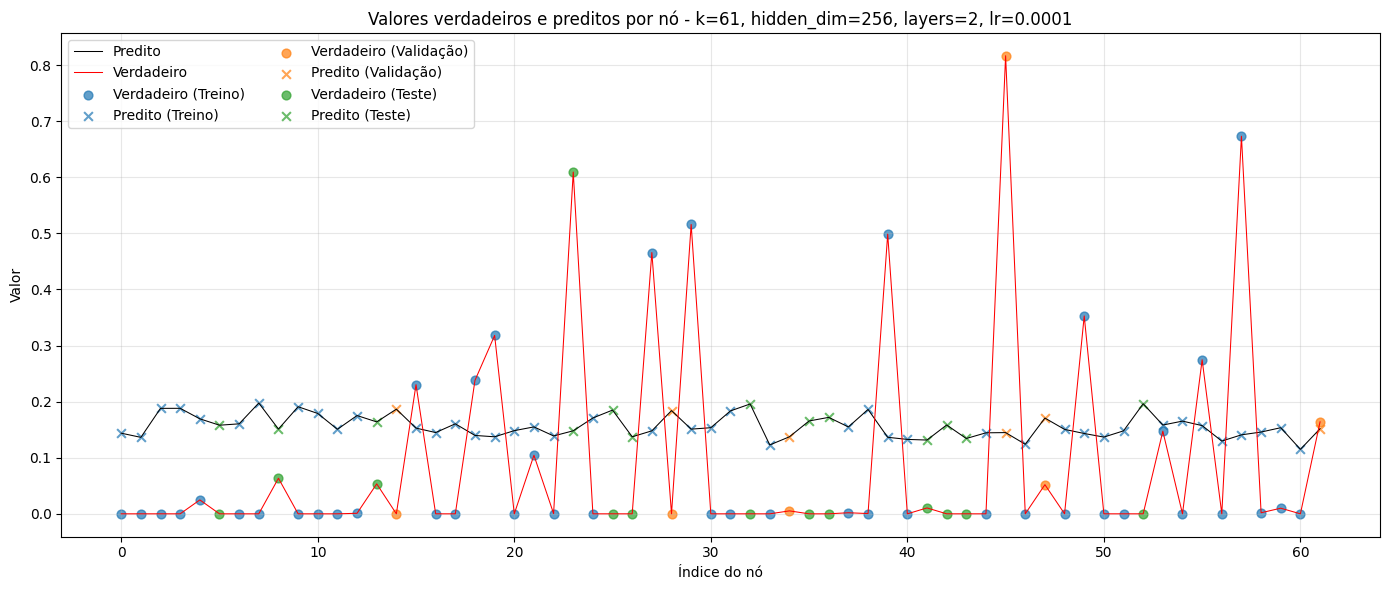

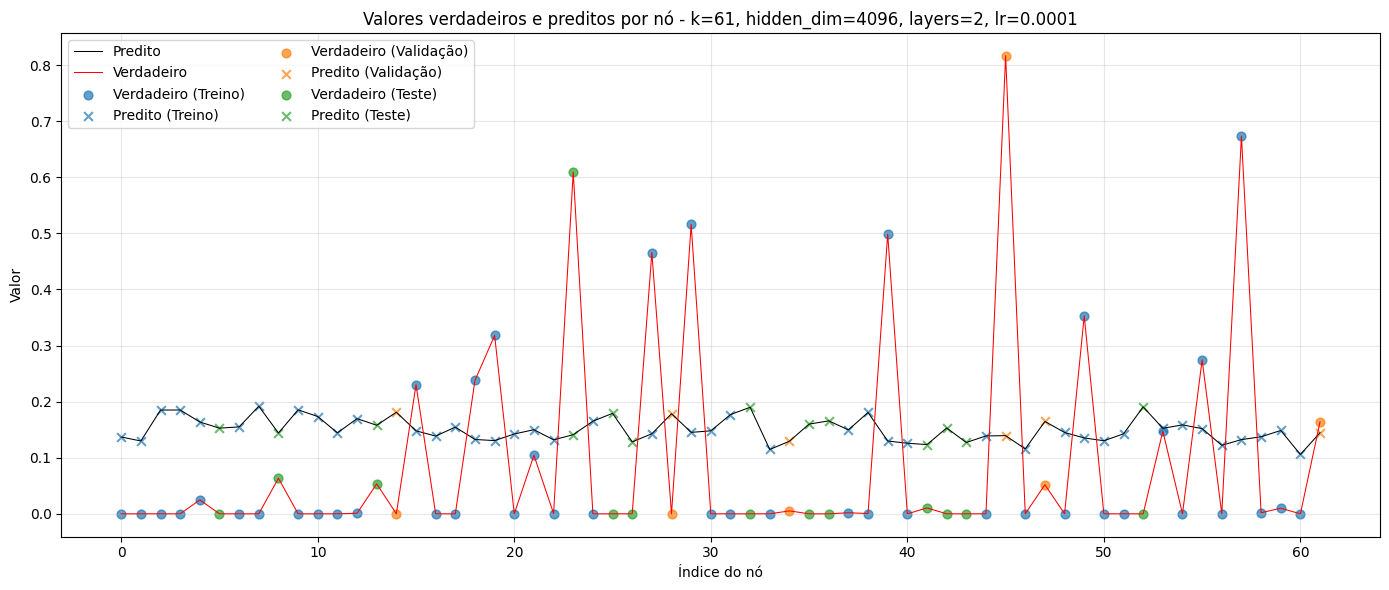

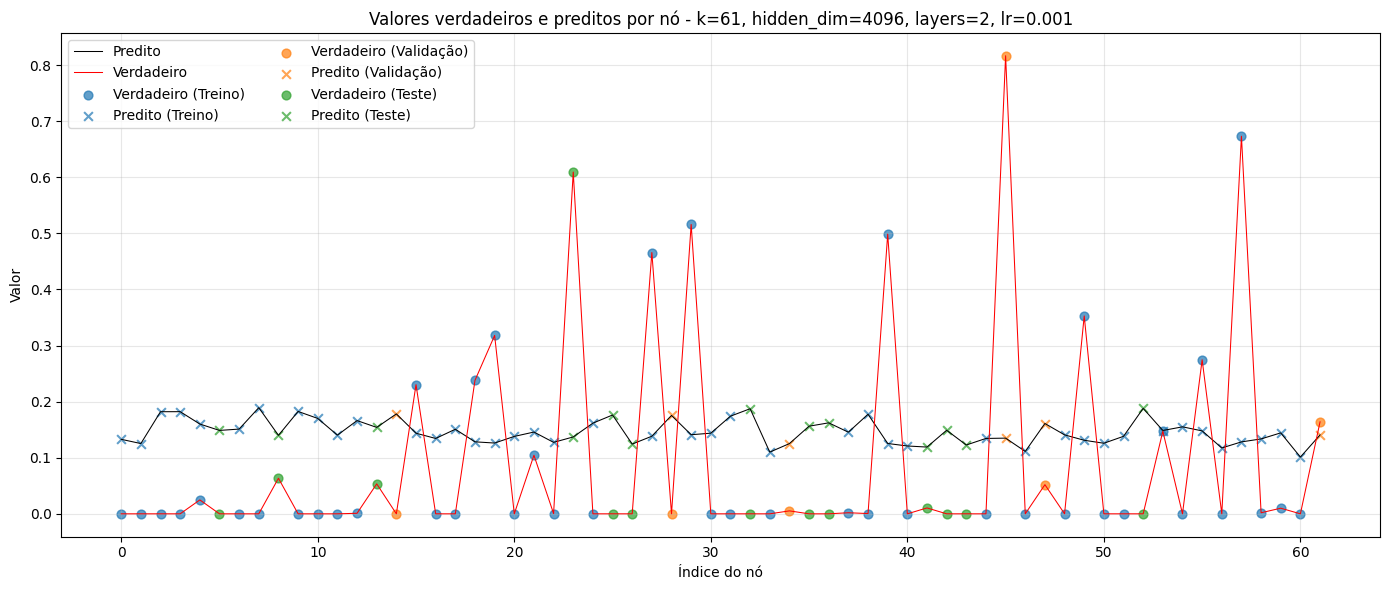

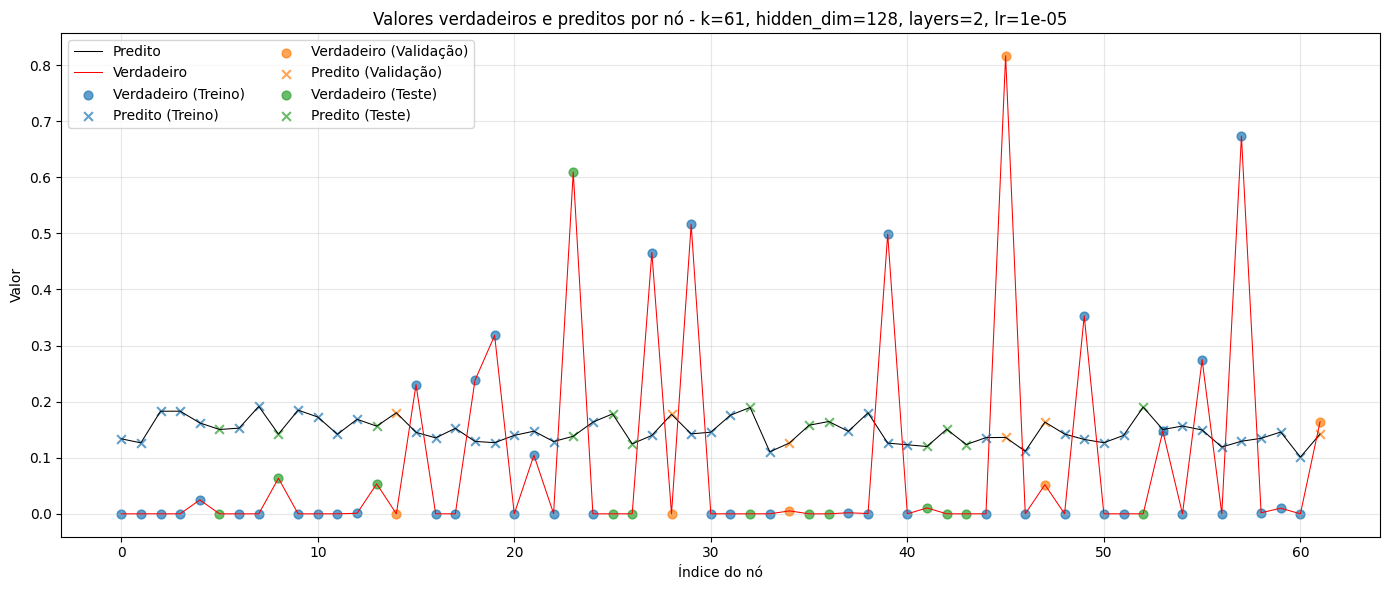

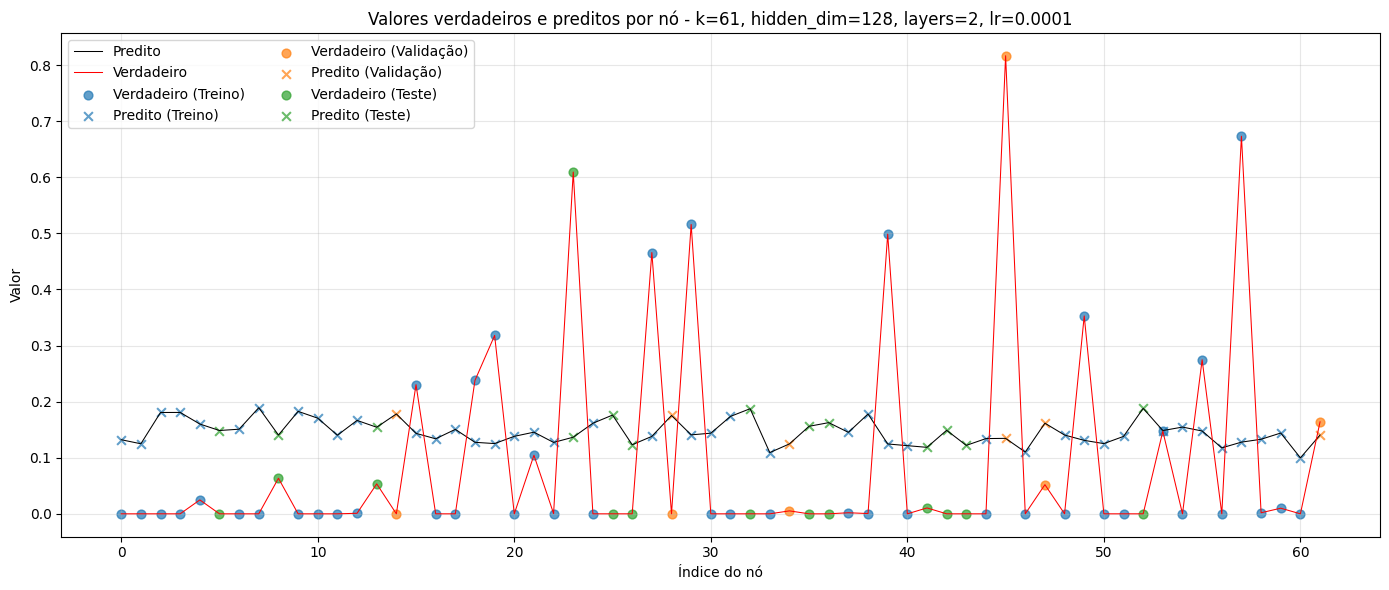

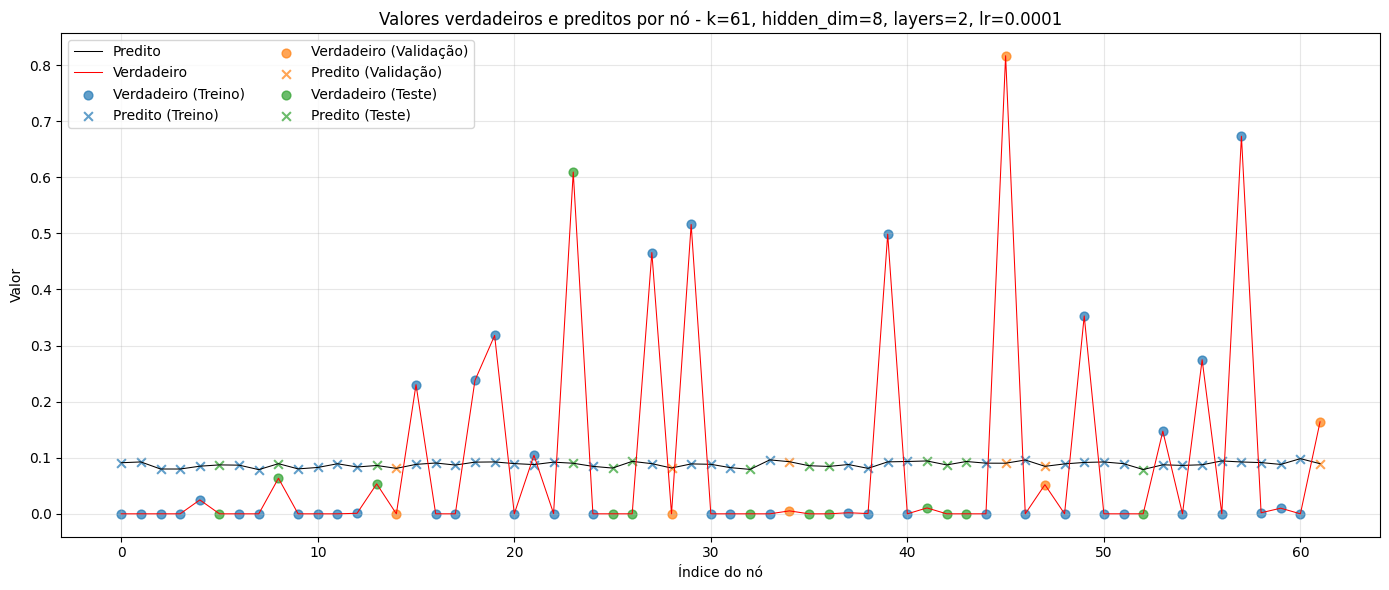

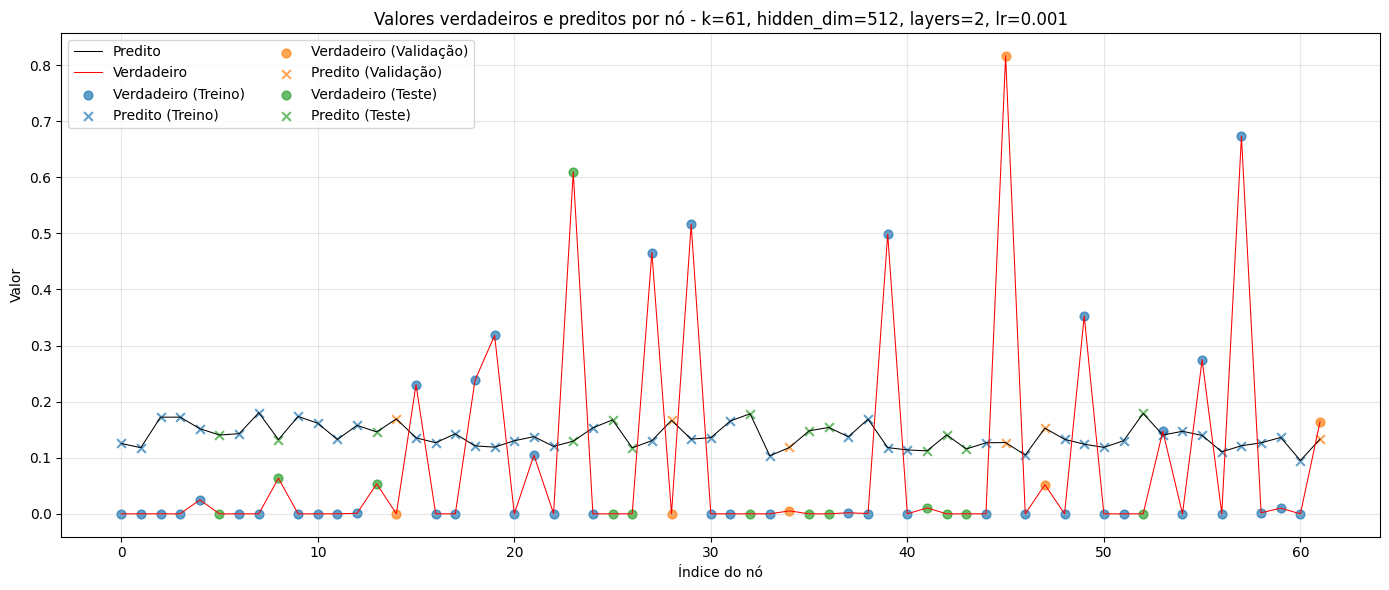

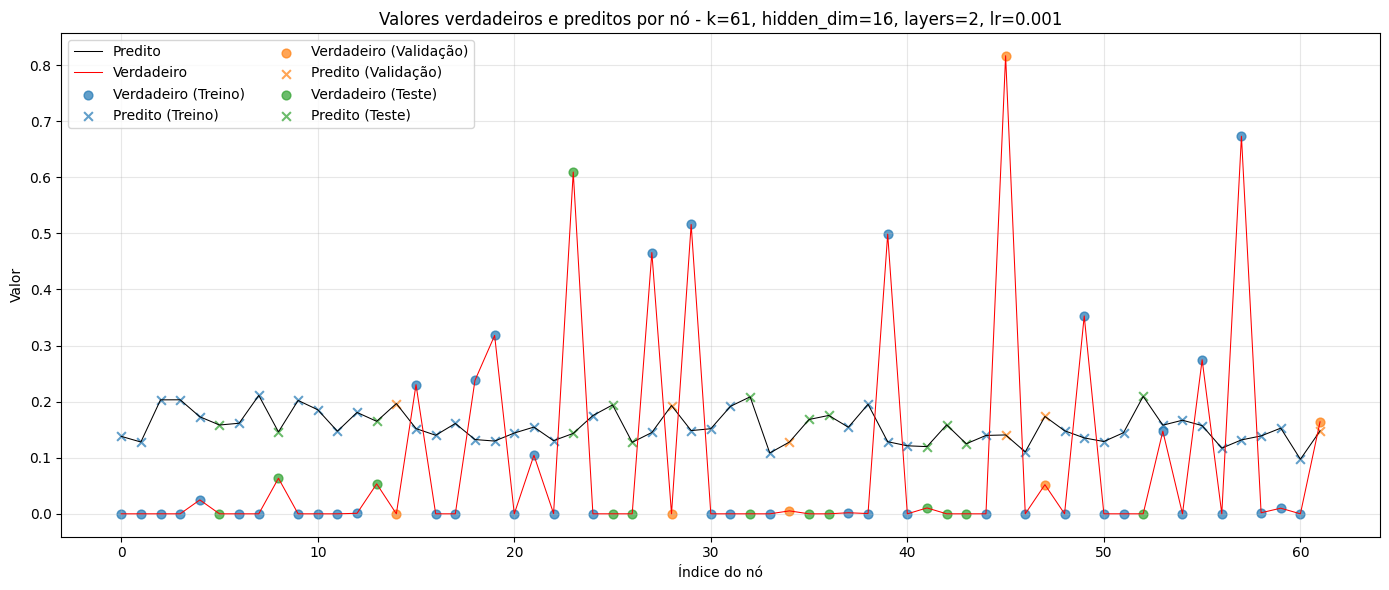

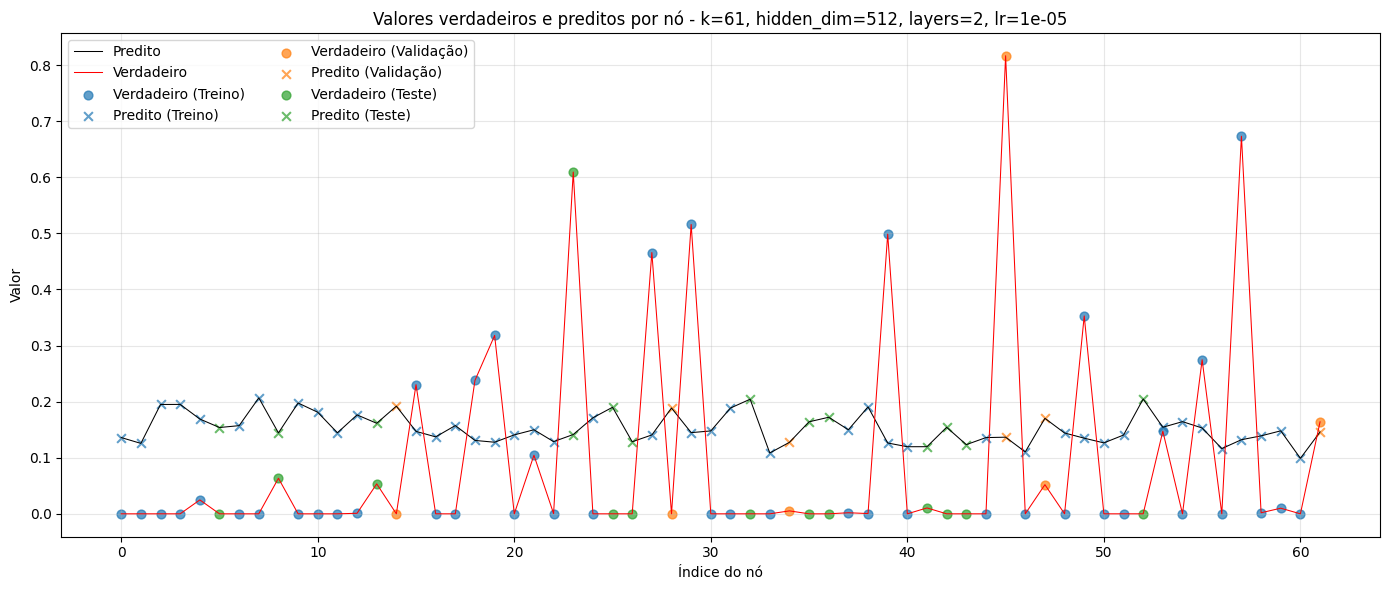

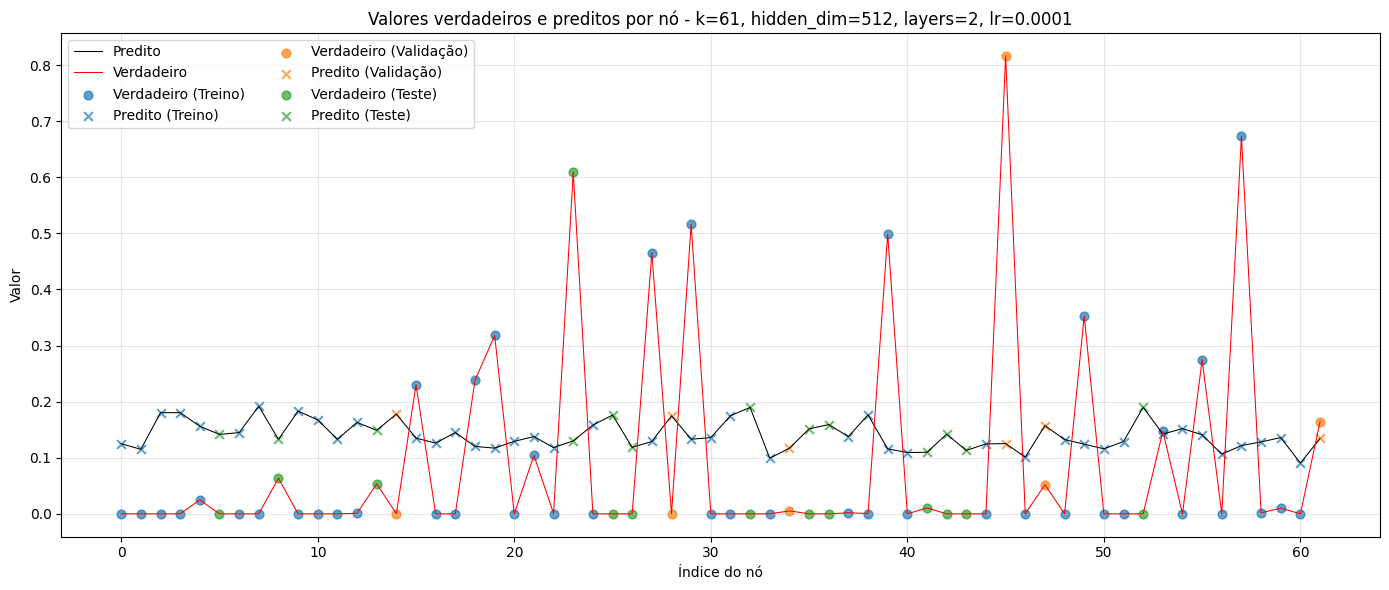

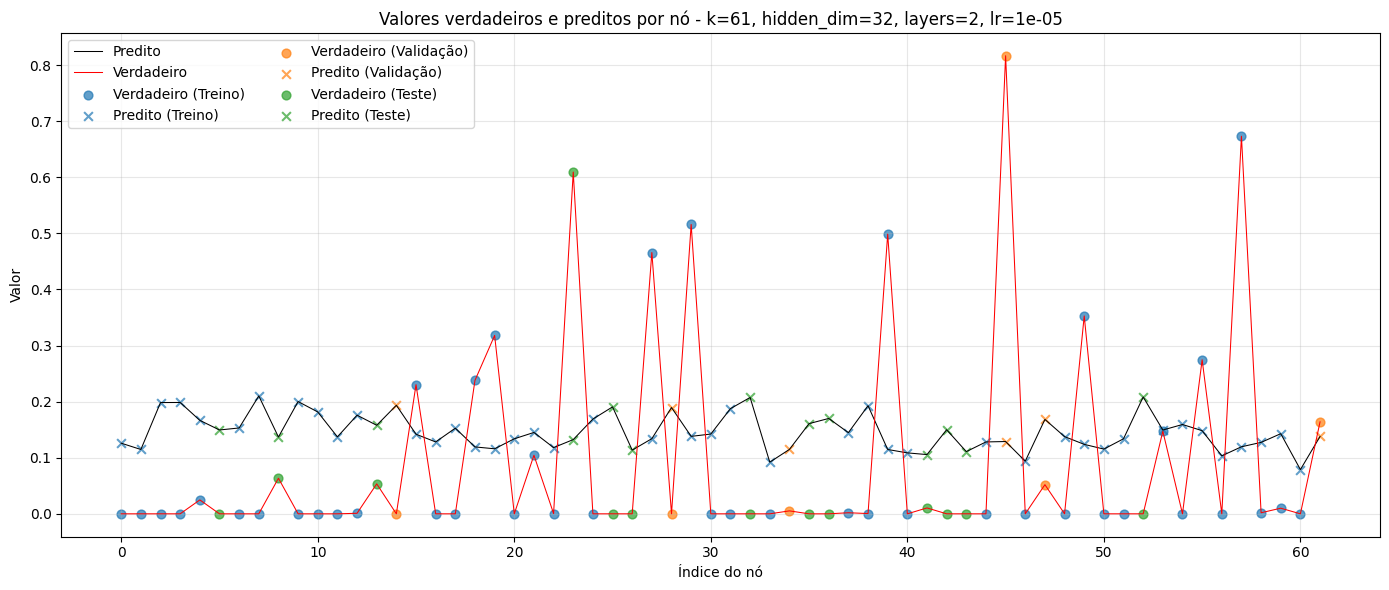

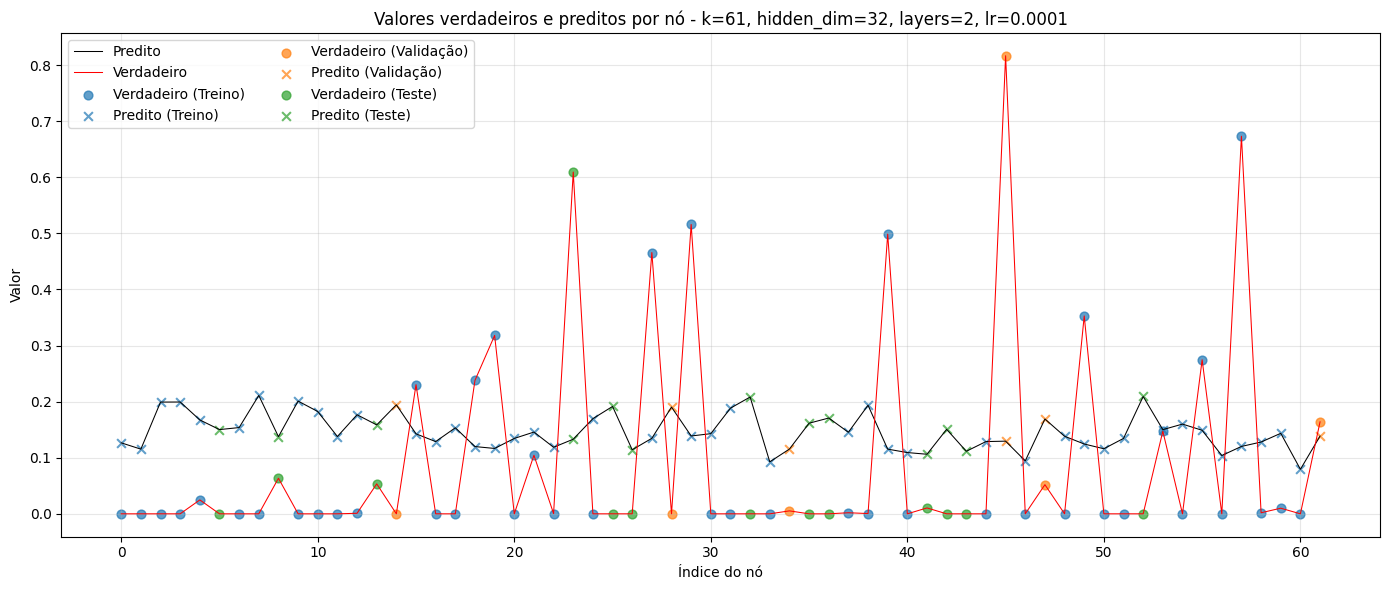

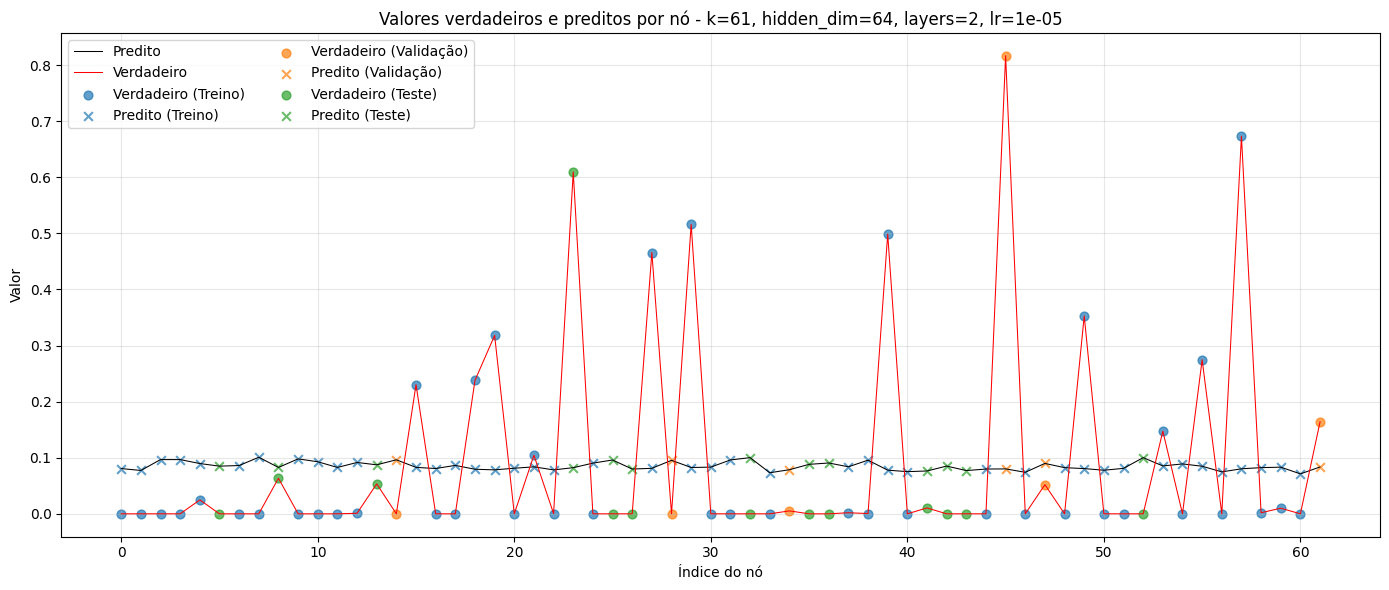

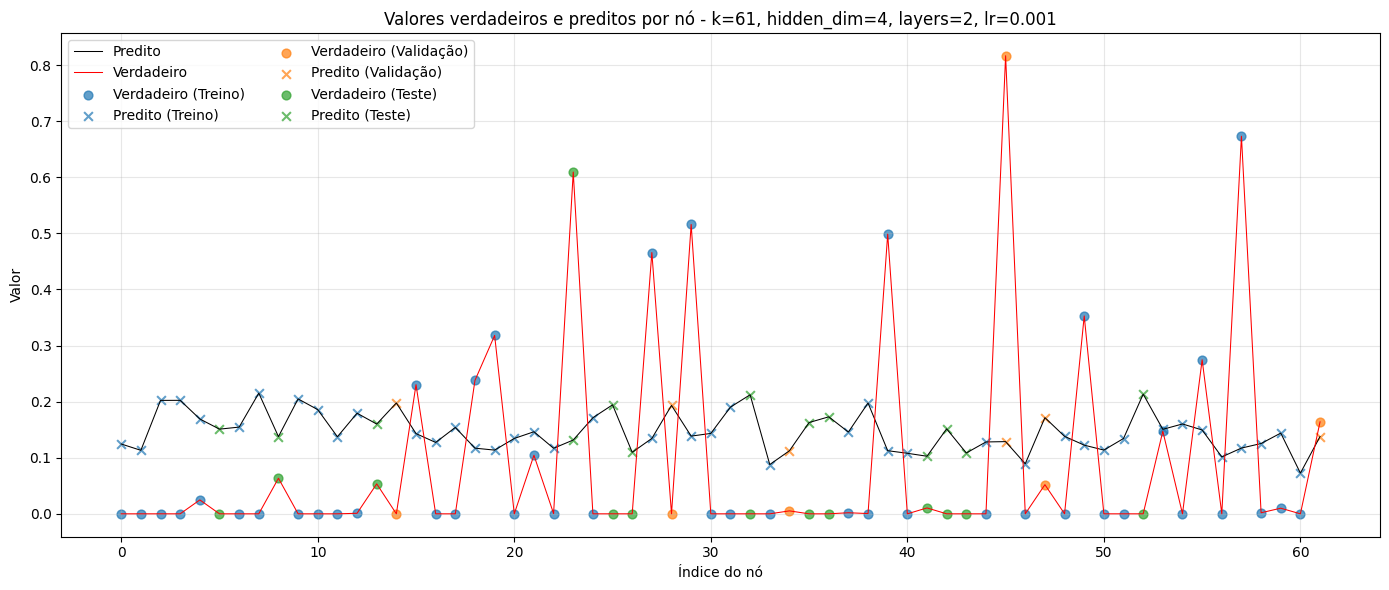

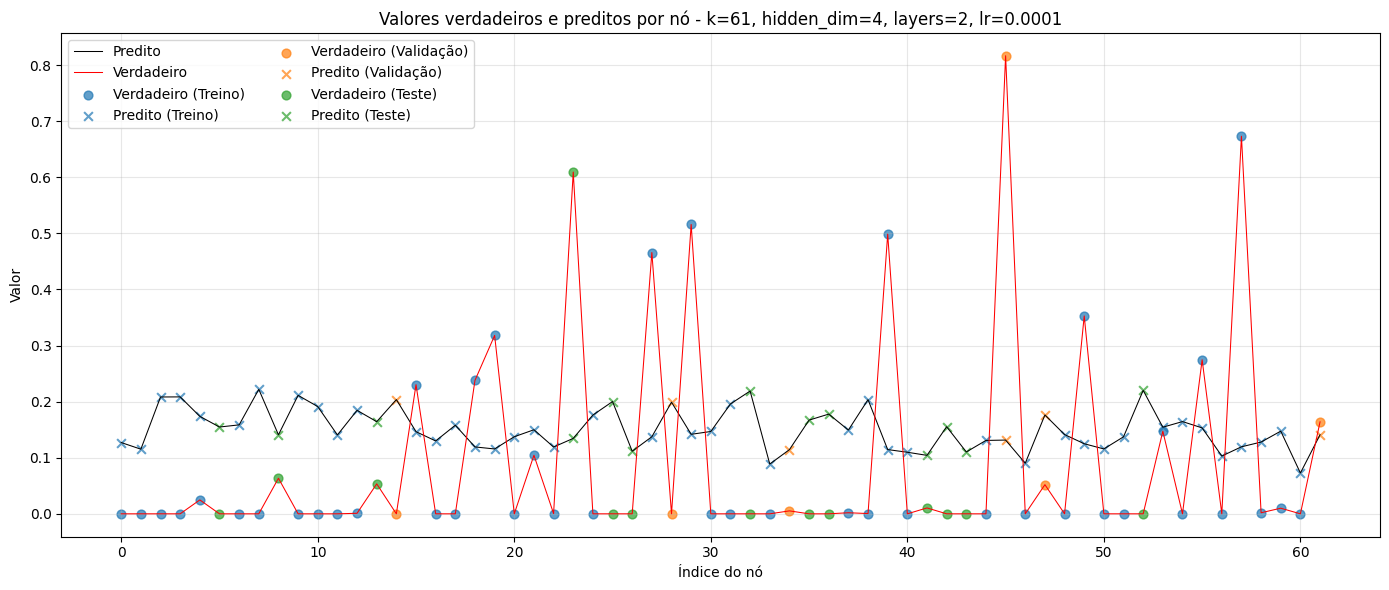

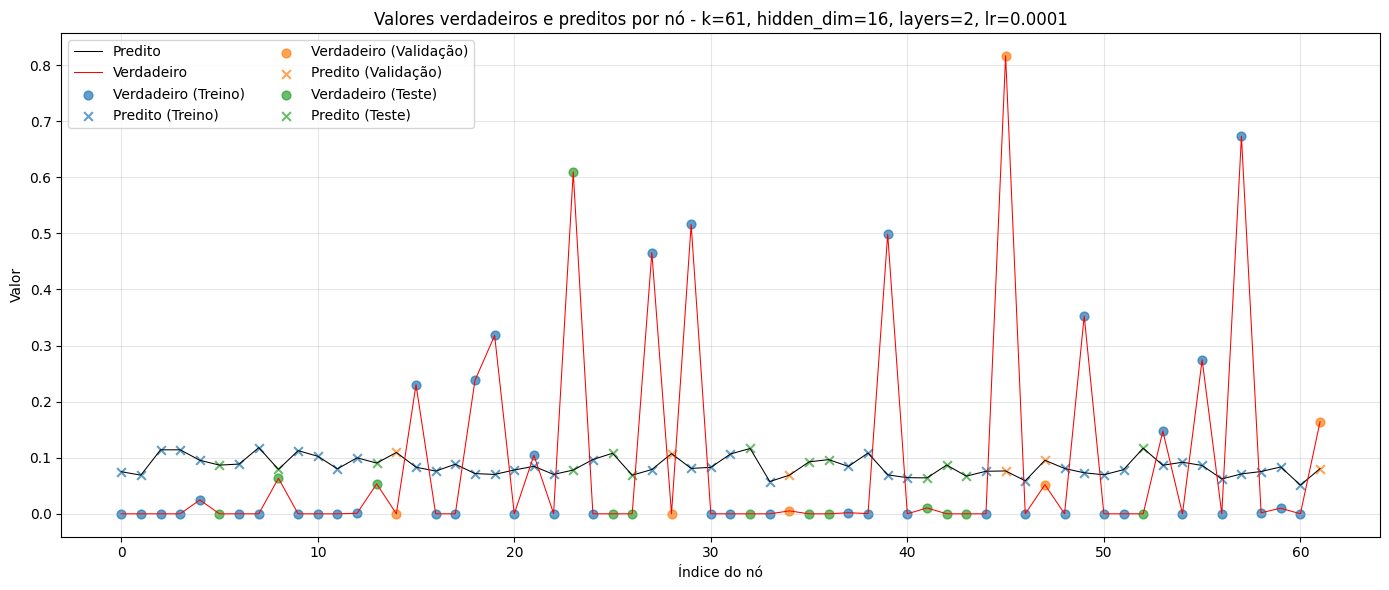

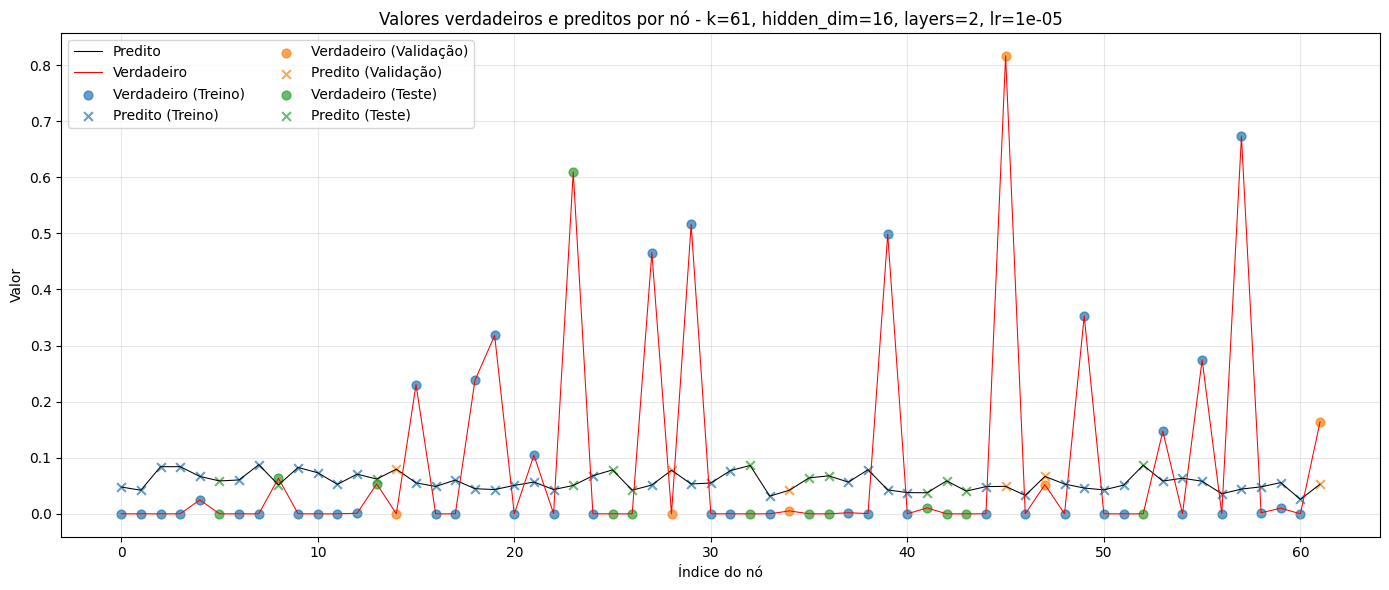

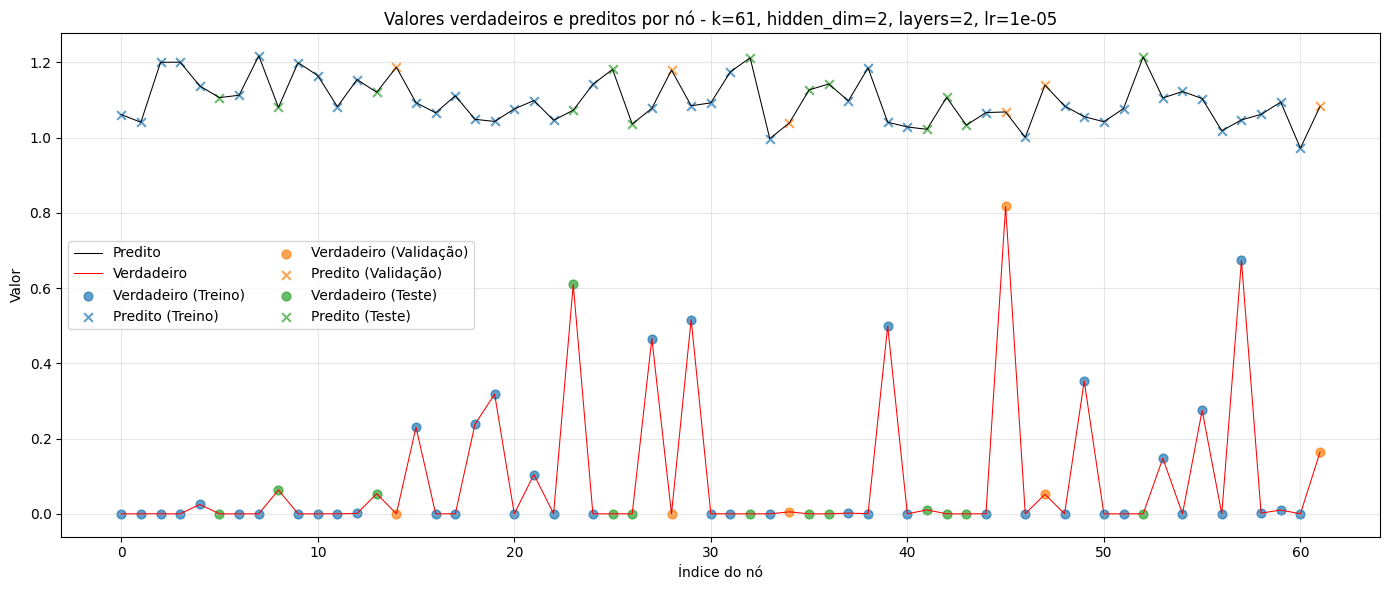

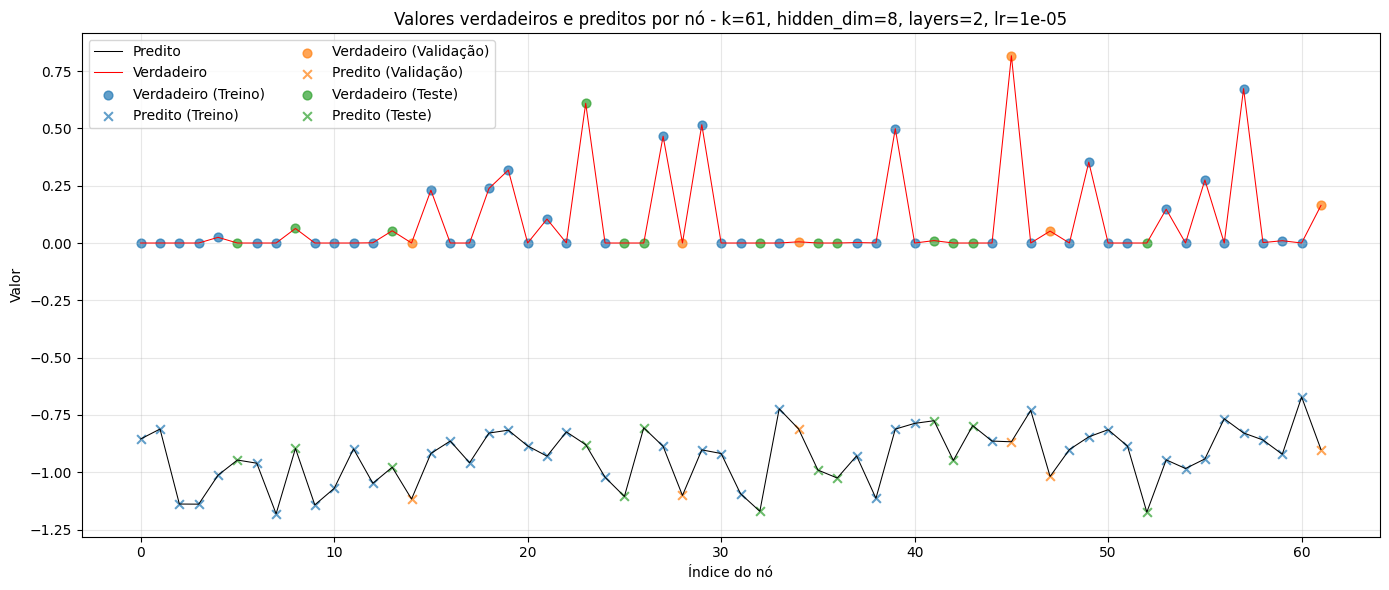

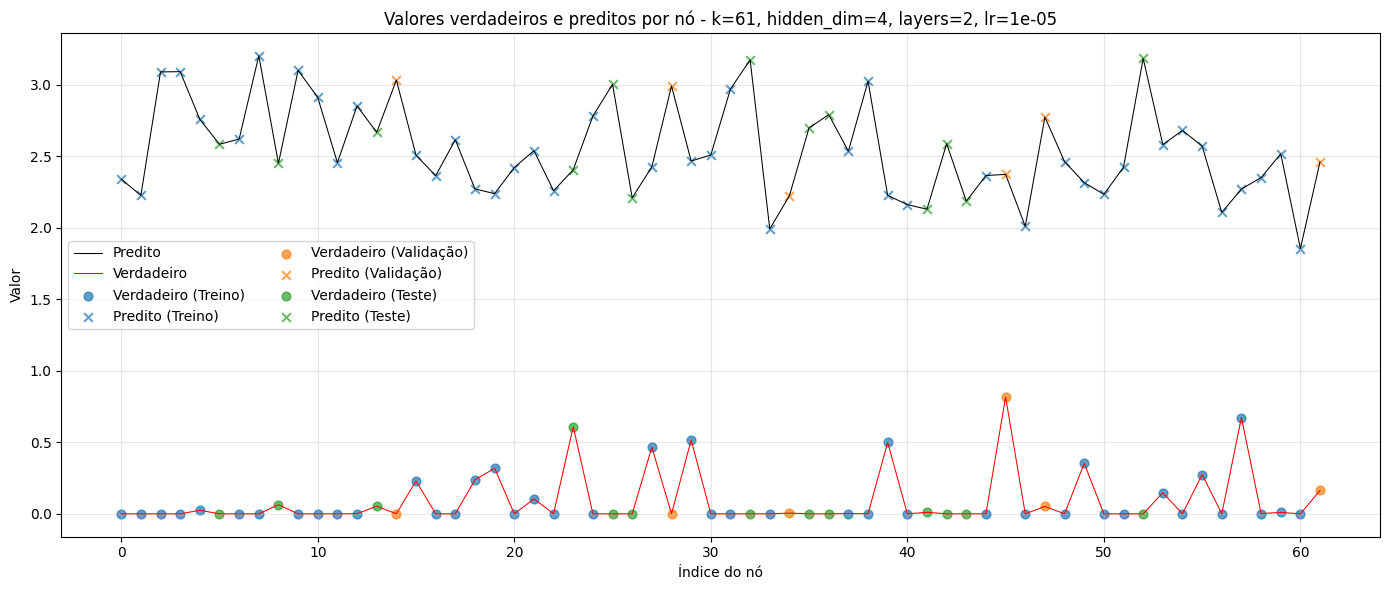

In [23]:
y_true = y.cpu().numpy()
idx_all = np.arange(len(y_true))

split_masks = {
    "Treino": mask_train,
    "Validação": mask_val,
    "Teste": mask_test,
}
colors = {
    "Treino": "tab:blue",
    "Validação": "tab:orange",
    "Teste": "tab:green",
}

def plot_predictions_by_node(ax, y_pred, row_dict, marker_size=40, legend_fontsize=10):
    ax.plot(
        idx_all,
        y_pred,
        color="black",
        linestyle="-",
        linewidth=0.75,
        label="Predito",
    )
    ax.plot(
        idx_all,
        y_true,
        color="red",
        linestyle="-",
        linewidth=0.75,
        label="Verdadeiro",
    )

    for label, mask in split_masks.items():
        node_idx = mask.nonzero(as_tuple=False).flatten().cpu().numpy()
        ax.scatter(
            node_idx,
            y_true[node_idx],
            color=colors[label],
            marker="o",
            s=marker_size,
            alpha=0.7,
            label=f"Verdadeiro ({label})",
        )
        ax.scatter(
            node_idx,
            y_pred[node_idx],
            color=colors[label],
            marker="x",
            s=marker_size,
            alpha=0.7,
            label=f"Predito ({label})",
        )

    ax.set_xlabel("Índice do nó")
    ax.set_ylabel("Valor")
    ax.set_title(
        "Valores verdadeiros e preditos por nó - "
        f"k={row_dict['k']}, hidden_dim={row_dict['hidden_dim']}, "
        f"layers={row_dict['n_hidden_layers']}, lr={row_dict['learning_rate']}"
    )
    ax.legend(ncol=2, fontsize=legend_fontsize)
    ax.grid(alpha=0.3)
    return ax


# Uma previsão por linha/configuração, na mesma ordem da tabela da Parte 7.
prediction_plot_rows = sorted(grid_rows, key=lambda row: row["loss_validation"])
for row_dict in prediction_plot_rows:
    history_key = tuple(row_dict[name] for name in grid_names)
    y_pred = grid_predictions_by_config[history_key]

    fig, ax = plt.subplots(figsize=(14, 6))
    plot_predictions_by_node(ax, y_pred, row_dict)
    plt.tight_layout()
    plt.show()

In [24]:
y_true = y.cpu().numpy()
idx = np.arange(len(y_true))

for hidden_dim in sorted(grid_predictions_by_hidden_dim):
    y_pred = grid_predictions_by_hidden_dim[hidden_dim]
    node_losses = np.square(y_pred - y_true)

    df_node_results = pd.DataFrame(
        {
            "hidden_dim": [hidden_dim] * len(y_true),
            "Índice": idx,
            "Estação": estacoes,
            "Valor verdadeiro": y_true,
            "Valor predito": y_pred,
            "Loss por nó (MSE)": node_losses,
        }
    )

    print(f"hidden_dim = {hidden_dim}")
    display(df_node_results.style.format(precision=6))

hidden_dim = 2


,hidden_dim,Índice,Estação,Valor verdadeiro,Valor predito,Loss por nó (MSE)
0,2,0,ACEGUA,0.000000,1.060947,1.125609
1,2,1,ALEGRETE,0.000000,1.040461,1.082559
2,2,2,BAGE,0.000000,1.199828,1.439587
3,2,3,BAGE - CENTRO,0.000000,1.200123,1.440295
4,2,4,BENTO GONCALVES,0.024796,1.136908,1.236795
5,2,5,CACAPAVA DO SUL,0.000000,1.105944,1.223111
6,2,6,CACHOEIRA DO SUL,0.000000,1.112393,1.237418
7,2,7,CACHOEIRINHA,0.000000,1.217291,1.481797
8,2,8,CAMBARA DO SUL,0.063419,1.080018,1.033472
9,2,9,CAMPO BOM,0.000000,1.198897,1.437355


hidden_dim = 4


,hidden_dim,Índice,Estação,Valor verdadeiro,Valor predito,Loss por nó (MSE)
0,4,0,ACEGUA,0.000000,2.339788,5.474607
1,4,1,ALEGRETE,0.000000,2.225627,4.953414
2,4,2,BAGE,0.000000,3.089312,9.543848
3,4,3,BAGE - CENTRO,0.000000,3.090790,9.552981
4,4,4,BENTO GONCALVES,0.024796,2.757197,7.466017
5,4,5,CACAPAVA DO SUL,0.000000,2.583257,6.673215
6,4,6,CACHOEIRA DO SUL,0.000000,2.619587,6.862237
7,4,7,CACHOEIRINHA,0.000000,3.202206,10.254121
8,4,8,CAMBARA DO SUL,0.063419,2.449642,5.694059
9,4,9,CAMPO BOM,0.000000,3.099886,9.609296


hidden_dim = 8


...

,hidden_dim,Índice,Estação,Valor verdadeiro,Valor predito,Loss por nó (MSE)
0,1024,0,ACEGUA,0.000000,0.143540,0.020604
1,1024,1,ALEGRETE,0.000000,0.139103,0.019350
2,1024,2,BAGE,0.000000,0.178430,0.031837
3,1024,3,BAGE - CENTRO,0.000000,0.178508,0.031865
4,1024,4,BENTO GONCALVES,0.024796,0.164078,0.019400
5,1024,5,CACAPAVA DO SUL,0.000000,0.156308,0.024432
6,1024,6,CACHOEIRA DO SUL,0.000000,0.157767,0.024891
7,1024,7,CACHOEIRINHA,0.000000,0.183912,0.033824
8,1024,8,CAMBARA DO SUL,0.063419,0.150285,0.007546
9,1024,9,CAMPO BOM,0.000000,0.179777,0.032320


hidden_dim = 2048


,hidden_dim,Índice,Estação,Valor verdadeiro,Valor predito,Loss por nó (MSE)
0,2048,0,ACEGUA,0.000000,0.140280,0.019678
1,2048,1,ALEGRETE,0.000000,0.133845,0.017915
2,2048,2,BAGE,0.000000,0.182256,0.033217
3,2048,3,BAGE - CENTRO,0.000000,0.182328,0.033243
4,2048,4,BENTO GONCALVES,0.024796,0.165248,0.019727
5,2048,5,CACAPAVA DO SUL,0.000000,0.154768,0.023953
6,2048,6,CACHOEIRA DO SUL,0.000000,0.156886,0.024613
7,2048,7,CACHOEIRINHA,0.000000,0.191193,0.036555
8,2048,8,CAMBARA DO SUL,0.063419,0.148181,0.007185
9,2048,9,CAMPO BOM,0.000000,0.185387,0.034368


hidden_dim = 4096


,hidden_dim,Índice,Estação,Valor verdadeiro,Valor predito,Loss por nó (MSE)
0,4096,0,ACEGUA,0.000000,0.133291,0.017767
1,4096,1,ALEGRETE,0.000000,0.127309,0.016208
2,4096,2,BAGE,0.000000,0.177467,0.031494
3,4096,3,BAGE - CENTRO,0.000000,0.177570,0.031531
4,4096,4,BENTO GONCALVES,0.024796,0.157684,0.017659
5,4096,5,CACAPAVA DO SUL,0.000000,0.148229,0.021972
6,4096,6,CACHOEIRA DO SUL,0.000000,0.150122,0.022537
7,4096,7,CACHOEIRINHA,0.000000,0.182461,0.033292
8,4096,8,CAMBARA DO SUL,0.063419,0.139809,0.005835
9,4096,9,CAMPO BOM,0.000000,0.176998,0.031328


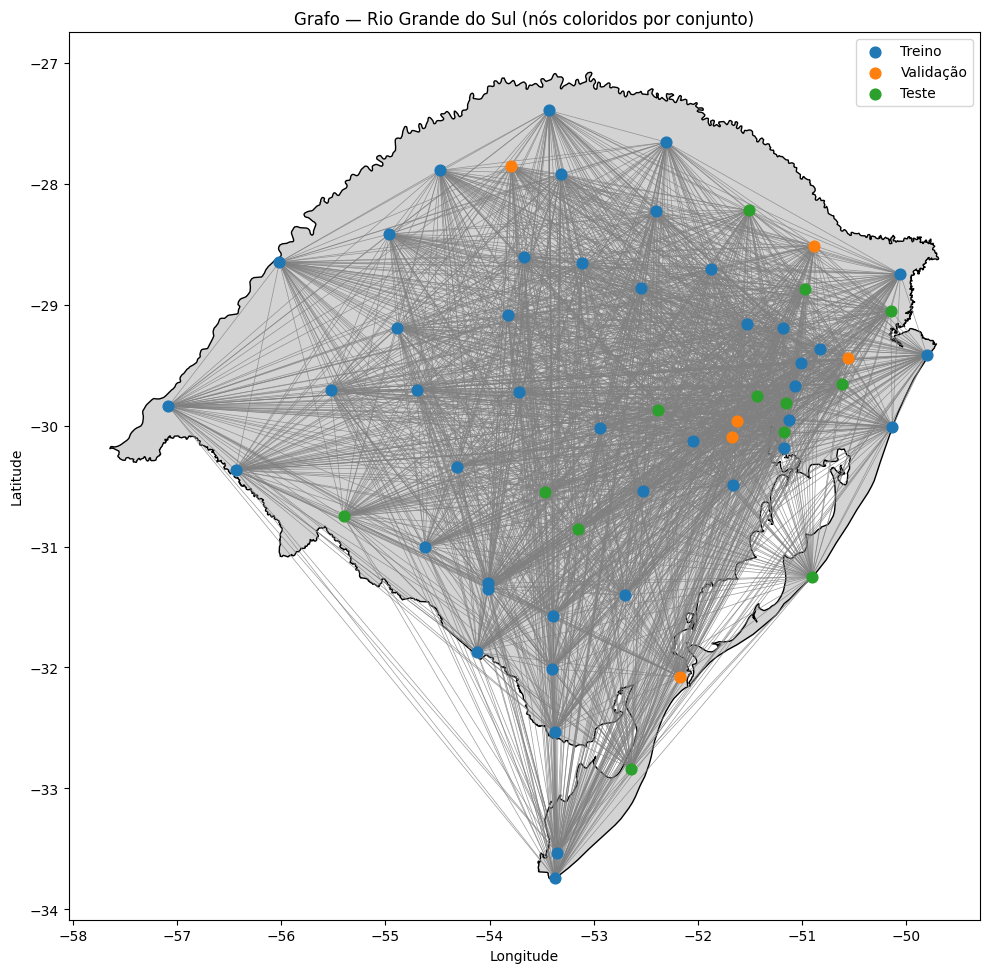

In [25]:
# Plot do grafo sobre o mapa do Rio Grande do Sul
# Nós coloridos por conjunto: Treino / Validação / Teste
colors_map = {'Treino':'tab:blue','Validação':'tab:orange','Teste':'tab:green'}
try:
    import geopandas as gpd
    # GeoJSON público com os estados do Brasil (usa GitHub)
    states = gpd.read_file(
        'https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson'
    )
    rs = states[states['name'].str.contains('Rio Grande do Sul', case=False, na=False)]

    df_nodes = pd.DataFrame({
        'lon': coords[:, 1],
        'lat': coords[:, 0],
        'Conjunto': [ 'Treino' if mask_train[i].item() else ('Validação' if mask_val[i].item() else 'Teste') for i in range(len(coords)) ],
    })
    gdf_nodes = gpd.GeoDataFrame(df_nodes, geometry=gpd.points_from_xy(df_nodes.lon, df_nodes.lat), crs='EPSG:4326')

    fig, ax = plt.subplots(figsize=(10,10))
    if not rs.empty:
        rs.plot(ax=ax, color='lightgray', edgecolor='black')

    # linhas das arestas (usar A_weighted para espessura/alpha)
    A = (A_weighted.cpu().numpy() > 0).astype(float)
    Nn = A.shape[0]
    for i in range(Nn):
        for j in range(i+1, Nn):
            w = A[i, j]
            if w > 0 and not np.isclose(w, 0):
                xs = [coords[i,1], coords[j,1]]
                ys = [coords[i,0], coords[j,0]]
                ax.plot(xs, ys, color='gray', linewidth=0.5, alpha=min(0.8, 0.3 + 0.7 * w))

    # plot dos nós por conjunto
    for label, color in colors_map.items():
        subset = gdf_nodes[gdf_nodes['Conjunto'] == label]
        subset.plot(ax=ax, color=color, markersize=60, label=label, zorder=3)

    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title('Grafo — Rio Grande do Sul (nós coloridos por conjunto)')
    ax.legend()
    plt.tight_layout()
    plt.show()

except Exception as e:
    print('Não foi possível carregar mapa externo — plotando sem mapa. Erro:', e)
    fig, ax = plt.subplots(figsize=(10,8))
    A = (A_weighted.cpu().numpy() > 0).astype(float)
    Nn = A.shape[0]
    for i in range(Nn):
        for j in range(i+1, Nn):
            w = A[i, j]
            if w > 0 and not np.isclose(w, 0):
                xs = [coords[i,1], coords[j,1]]
                ys = [coords[i,0], coords[j,0]]
                ax.plot(xs, ys, color='gray', linewidth=0.5, alpha=min(0.8, 0.3 + 0.7 * w))

    # desenhar nós separados por conjunto
    for label, color in colors_map.items():
        idx = [i for i in range(len(coords)) if (mask_train[i].item() and label == 'Treino') or (mask_val[i].item() and label == 'Validação') or (mask_test[i].item() and label == 'Teste')]
        if len(idx) > 0:
            ax.scatter(coords[idx,1], coords[idx,0], c=color, s=60, label=label, edgecolor='k', zorder=3)

    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.set_title('Grafo — (sem mapa)')
    ax.legend()
    plt.tight_layout()
    plt.show()


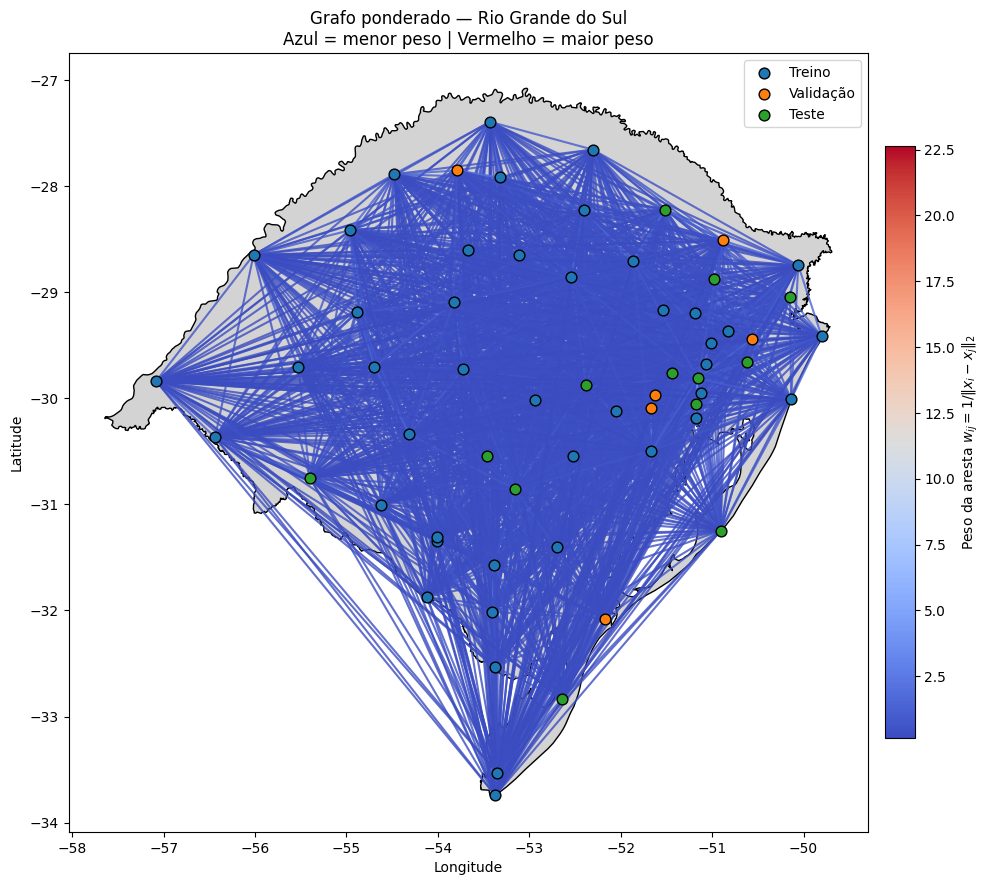

In [26]:
# Plot do grafo sobre o mapa do Rio Grande do Sul
# Nós coloridos por conjunto: Treino / Validação / Teste
# Arestas: azul = menor peso / vermelho = maior peso

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

colors_map = {
    'Treino': 'tab:blue',
    'Validação': 'tab:orange',
    'Teste': 'tab:green'
}

try:
    import geopandas as gpd

    # GeoJSON público com os estados do Brasil
    states = gpd.read_file(
        'https://raw.githubusercontent.com/codeforamerica/'
        'click_that_hood/master/public/data/brazil-states.geojson'
    )

    rs = states[
        states['name'].str.contains(
            'Rio Grande do Sul',
            case=False,
            na=False
        )
    ]

    # DataFrame dos nós
    df_nodes = pd.DataFrame({
        'lon': coords[:, 1],
        'lat': coords[:, 0],
        'Conjunto': [
            'Treino'
            if mask_train[i].item()
            else (
                'Validação'
                if mask_val[i].item()
                else 'Teste'
            )
            for i in range(len(coords))
        ],
    })

    gdf_nodes = gpd.GeoDataFrame(
        df_nodes,
        geometry=gpd.points_from_xy(
            df_nodes.lon,
            df_nodes.lat
        ),
        crs='EPSG:4326'
    )

    fig, ax = plt.subplots(figsize=(10, 10))

    if not rs.empty:
        rs.plot(
            ax=ax,
            color='lightgray',
            edgecolor='black'
        )

    # ==================================================
    # MATRIZ COM OS PESOS REAIS
    # ==================================================

    A = A_weighted.detach().cpu().numpy()

    Nn = A.shape[0]

    # Pegar somente pesos das arestas entre nós diferentes
    edge_weights = []

    for i in range(Nn):
        for j in range(i + 1, Nn):
            if A[i, j] > 0:
                edge_weights.append(A[i, j])

    edge_weights = np.asarray(edge_weights)

    # ==================================================
    # NORMALIZAÇÃO PARA O MAPA DE CORES
    # ==================================================

    vmin = edge_weights.min()
    vmax = edge_weights.max()

    norm = mpl.colors.Normalize(
        vmin=vmin,
        vmax=vmax
    )

    # Azul -> branco -> vermelho
    cmap = plt.cm.coolwarm

    # ==================================================
    # DESENHAR ARESTAS
    # ==================================================

    for i in range(Nn):
        for j in range(i + 1, Nn):

            w = A[i, j]

            if w > 0:

                xs = [
                    coords[i, 1],
                    coords[j, 1]
                ]

                ys = [
                    coords[i, 0],
                    coords[j, 0]
                ]

                # Cor baseada no peso
                edge_color = cmap(norm(w))

                ax.plot(
                    xs,
                    ys,
                    color=edge_color,
                    linewidth=1.5,
                    alpha=0.8,
                    zorder=2
                )

    # ==================================================
    # DESENHAR NÓS
    # ==================================================

    for label, color in colors_map.items():

        subset = gdf_nodes[
            gdf_nodes['Conjunto'] == label
        ]

        subset.plot(
            ax=ax,
            color=color,
            markersize=60,
            label=label,
            edgecolor='black',
            zorder=3
        )

    # ==================================================
    # BARRA DE CORES DOS PESOS
    # ==================================================

    sm = mpl.cm.ScalarMappable(
        cmap=cmap,
        norm=norm
    )

    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=ax,
        fraction=0.035,
        pad=0.02
    )

    cbar.set_label(
        r'Peso da aresta $w_{ij}=1/\|x_i-x_j\|_2$'
    )

    # ==================================================
    # CONFIGURAÇÕES DO GRÁFICO
    # ==================================================

    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

    ax.set_title(
        'Grafo ponderado — Rio Grande do Sul\n'
        'Azul = menor peso | Vermelho = maior peso'
    )

    ax.legend()

    plt.tight_layout()
    plt.show()


except Exception as e:

    print(
        'Não foi possível carregar mapa externo — '
        'plotando sem mapa. Erro:',
        e
    )

    fig, ax = plt.subplots(figsize=(10, 8))

    # Pesos reais
    A = A_weighted.detach().cpu().numpy()

    Nn = A.shape[0]

    edge_weights = []

    for i in range(Nn):
        for j in range(i + 1, Nn):
            if A[i, j] > 0:
                edge_weights.append(A[i, j])

    edge_weights = np.asarray(edge_weights)

    norm = mpl.colors.Normalize(
        vmin=edge_weights.min(),
        vmax=edge_weights.max()
    )

    cmap = plt.cm.coolwarm

    # Arestas
    for i in range(Nn):
        for j in range(i + 1, Nn):

            w = A[i, j]

            if w > 0:

                xs = [
                    coords[i, 1],
                    coords[j, 1]
                ]

                ys = [
                    coords[i, 0],
                    coords[j, 0]
                ]

                ax.plot(
                    xs,
                    ys,
                    color=cmap(norm(w)),
                    linewidth=1.5,
                    alpha=0.8,
                    zorder=2
                )

    # Nós
    for label, color in colors_map.items():

        idx = [
            i for i in range(len(coords))

            if (
                mask_train[i].item()
                and label == 'Treino'
            )
            or (
                mask_val[i].item()
                and label == 'Validação'
            )
            or (
                mask_test[i].item()
                and label == 'Teste'
            )
        ]

        if len(idx) > 0:

            ax.scatter(
                coords[idx, 1],
                coords[idx, 0],
                c=color,
                s=60,
                label=label,
                edgecolor='k',
                zorder=3
            )

    # Barra de cores
    sm = mpl.cm.ScalarMappable(
        cmap=cmap,
        norm=norm
    )

    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=ax,
        fraction=0.035,
        pad=0.02
    )

    cbar.set_label(
        r'Peso da aresta $w_{ij}=1/\|x_i-x_j\|_2$'
    )

    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

    ax.set_title(
        'Grafo ponderado\n'
        'Azul = menor peso | Vermelho = maior peso'
    )

    ax.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
from matplotlib.backends.backend_pdf import PdfPages
# Nome identificador da função de peso usada
weight_name = "inverso_da_distancia"

# Formata a data como YYYY-MM-DD
date_name = pd.Timestamp(target_date).strftime("%Y-%m-%d")

def export_grid_results_report(
    output_dir=None,
    pdf_name = f"WeightedEdges_{date_name}_{weight_name}.pdf",
    tex_name = f"WeightedEdges_{date_name}_{weight_name}.tex"
):
    output_dir = (
        Path(output_dir).resolve()
        if output_dir is not None
        else project_dir / "Results" / "WeightedEdges_report"
    )
    images_dir = output_dir / "images"
    output_dir.mkdir(parents=True, exist_ok=True)
    images_dir.mkdir(parents=True, exist_ok=True)

    pdf_path = output_dir / pdf_name
    tex_path = output_dir / tex_name

    y_true = y.cpu().numpy()
    idx_all = np.arange(len(y_true))

    split_masks = {
        "Treino": mask_train,
        "Validação": mask_val,
        "Teste": mask_test,
    }
    colors = {
        "Treino": "tab:blue",
        "Validação": "tab:orange",
        "Teste": "tab:green",
    }
    table_keys = [
        "k",
        "epochs",
        "hidden_dim",
        "n_hidden_layers",
        "learning_rate",
        "best_epoch",
        "stop_epoch",
        "loss_train",
        "loss_validation",
        "loss_test",
    ]

    def format_value(key, value):
        if key in {"k", "epochs", "hidden_dim", "n_hidden_layers", "best_epoch", "stop_epoch"}:
            return str(int(value))
        if key == "learning_rate":
            return f"{value:.3g}"
        return f"{value:.6f}"

    def build_page_figure(row_dict, history_run, y_pred, ix):
        # Uma figura A4 completa: a mesma página é usada no PDF e no LaTeX.
        fig = plt.figure(figsize=(8.27, 11.69), layout="constrained")
        gs = fig.add_gridspec(
            nrows=3, ncols=1, height_ratios=[1.15, 3.1, 3.5], hspace=0.08
        )

        ax_table = fig.add_subplot(gs[0, 0])
        ax_loss = fig.add_subplot(gs[1, 0])
        ax_pred = fig.add_subplot(gs[2, 0])

        ax_table.axis("off")
        half = (len(table_keys) + 1) // 2
        table_data = []
        for pos in range(half):
            left_key = table_keys[pos]
            right_pos = pos + half
            row = [
                left_key.replace("_", " "),
                format_value(left_key, row_dict[left_key]),
            ]
            if right_pos < len(table_keys):
                right_key = table_keys[right_pos]
                row.extend([
                    right_key.replace("_", " "),
                    format_value(right_key, row_dict[right_key]),
                ])
            else:
                row.extend(["", ""])
            table_data.append(row)

        result_table = ax_table.table(
            cellText=table_data,
            colLabels=["Parâmetro", "Valor", "Parâmetro", "Valor"],
            colWidths=[0.29, 0.18, 0.29, 0.18],
            cellLoc="center",
            loc="center",
            bbox=[0.0, 0.0, 1.0, 0.86],
        )
        result_table.auto_set_font_size(False)
        result_table.set_fontsize(8.5)
        for col in range(4):
            result_table[(0, col)].set_facecolor("#d9e8f5")
            result_table[(0, col)].set_text_props(weight="bold")
        ax_table.set_title(
            f"Configuração {ix + 1} - linha da tabela ordenada por loss de validação",
            fontsize=11,
            weight="bold",
            pad=4,
        )

        epochs_executed = range(len(history_run["train"]))
        ax_loss.plot(epochs_executed, history_run["train"], label="Treino")
        ax_loss.plot(epochs_executed, history_run["validation"], label="Validação")
        ax_loss.plot(epochs_executed, history_run["test"], label="Teste")
        ax_loss.axvline(
            row_dict["stop_epoch"],
            color="gray",
            linestyle="--",
            label=f"Parada: {row_dict['stop_epoch']}",
        )
        ax_loss.set(
            title=(
                "Weighted GNN - configuração: "
                f"k={row_dict['k']}, hidden={row_dict['hidden_dim']}, "
                f"lr={row_dict['learning_rate']}"
            ),
            xlabel="Época",
            ylabel="MSE Loss",
        )
        ax_loss.grid(alpha=0.3)
        ax_loss.legend(fontsize=8)

        # Chama exatamente a mesma função usada pelo gráfico da Parte 7.
        plot_predictions_by_node(
            ax_pred, y_pred, row_dict, marker_size=40, legend_fontsize=7
        )
        return fig

    with PdfPages(pdf_path) as pdf_file, open(tex_path, "w", encoding="utf-8") as tex_file:
        tex_file.write(
            "\\documentclass[a4paper]{article}\n"
            "\\usepackage[margin=8mm]{geometry}\n"
            "\\usepackage{graphicx}\n"
            "\\pagestyle{empty}\n"
            "\\setlength{\\parindent}{0pt}\n"
            "\\begin{document}\n"
        )

        # A Parte 7 exibe a tabela nesta ordem.
        report_rows = sorted(grid_rows, key=lambda row: row["loss_validation"])

        for ix, row_dict in enumerate(report_rows):
            history_key = tuple(row_dict[name] for name in grid_names)
            history_run = grid_histories[history_key]
            y_pred = grid_predictions_by_config[history_key]

            fig = build_page_figure(row_dict, history_run, y_pred, ix)
            pdf_file.savefig(fig)
            page_stem = f"config_{ix + 1:03d}_page"
            page_pdf_path = images_dir / f"{page_stem}.pdf"
            page_png_path = images_dir / f"{page_stem}.png"
            fig.savefig(page_pdf_path, format="pdf")
            fig.savefig(page_png_path, dpi=180)
            plt.close(fig)

            if ix > 0:
                tex_file.write("\\clearpage\n")
            # Inclui a página vetorial completa: tabela e gráficos nunca se separam.
            tex_file.write(
                "\\noindent\\includegraphics"
                "[width=\\textwidth,height=\\textheight,keepaspectratio]"
                f"{{images/{page_stem}.pdf}}\n"
            )

        tex_file.write("\\end{document}\n")

    print(f"Relatório PDF salvo em: {pdf_path}")
    print(f"Arquivo LaTeX salvo em: {tex_path}")


# Executar exportação automaticamente se desejar.
export_grid_results_report()


Relatório PDF salvo em: C:\Users\loren\GNNGCN-proj\Results\WeightedEdges_report\WeightedEdges_2025-02-08_inverso_da_distancia.pdf
Arquivo LaTeX salvo em: C:\Users\loren\GNNGCN-proj\Results\WeightedEdges_report\WeightedEdges_2025-02-08_inverso_da_distancia.tex


In [ ]:
# Melhor configuração pelo menor MSE médio considerando todos os nós.
# Atenção: esta análise inclui os nós de treino, validação e teste.

y_true_all_nodes = y.detach().cpu().numpy()
global_mse_rows = []

for row_dict in grid_rows:
    config_key = tuple(
        row_dict[name]
        for name in grid_names
    )

    y_pred_config = np.asarray(
        grid_predictions_by_config[config_key]
    )

    # Para cada nó: (predito - verdadeiro)²
    mse_by_node = np.square(
        y_pred_config - y_true_all_nodes
    )

    global_mse_rows.append({
        **row_dict,
        "mse_mean_all_nodes": float(mse_by_node.mean()),
    })


# Tabela ordenada do menor para o maior MSE médio
global_mse_results = (
    pd.DataFrame(global_mse_rows)
    .sort_values("mse_mean_all_nodes")
    .reset_index(drop=True)
)


# Configuração com menor MSE médio
best_global_mse_run = min(
    global_mse_rows,
    key=lambda row: row["mse_mean_all_nodes"],
)

best_global_mse_config = {
    name: best_global_mse_run[name]
    for name in grid_names
}

best_global_mse_key = tuple(
    best_global_mse_config[name]
    for name in grid_names
)

best_global_mse_predictions = np.asarray(
    grid_predictions_by_config[best_global_mse_key]
)


# Resultado individual dos nós para a melhor configuração
best_global_mse_by_node = pd.DataFrame({
    "Índice": np.arange(len(y_true_all_nodes)),
    "Estação": estacoes,
    "Valor verdadeiro": y_true_all_nodes,
    "Valor predito": best_global_mse_predictions,
    "MSE do nó": np.square(
        best_global_mse_predictions - y_true_all_nodes
    ),
})


print("Configurações ordenadas pelo MSE médio de todos os nós:")

display(
    global_mse_results.style.format({
        "learning_rate": "{:.6g}",
        "loss_train": "{:.6f}",
        "loss_validation": "{:.6f}",
        "loss_test": "{:.6f}",
        "mse_mean_all_nodes": "{:.6f}",
    })
)


print("\nMelhor configuração global:")

for name, value in best_global_mse_config.items():
    print(f"{name}: {value}")

print(
    "\nMSE médio de todos os nós: "
    f"{best_global_mse_run['mse_mean_all_nodes']:.6f}"
)


print("\nMSE individual dos nós da melhor configuração:")

display(
    best_global_mse_by_node.style.format({
        "Valor verdadeiro": "{:.6f}",
        "Valor predito": "{:.6f}",
        "MSE do nó": "{:.6f}",
    })
)

Configurações ordenadas pelo MSE médio de todos os nós:


,k,epochs,hidden_dim,n_hidden_layers,learning_rate,best_epoch,stop_epoch,loss_train,loss_validation,loss_test,mse_mean_all_nodes
0,61,2000,32,2,0.001,1972,2000,0.028466,0.088164,0.025211,0.033561
1,61,2000,8,2,0.001,1870,2000,0.029199,0.091874,0.026057,0.034606
2,61,2000,8,2,0.0001,1686,2000,0.029502,0.092587,0.026515,0.034981
3,61,2000,64,2,1e-05,1833,2000,0.030443,0.095741,0.027370,0.036118
4,61,2000,16,2,0.0001,1980,2000,0.031342,0.097429,0.028310,0.037101
5,61,2000,16,2,1e-05,2000,2000,0.032373,0.102636,0.027179,0.038084
6,61,2000,64,2,0.0001,8,1008,0.033889,0.091398,0.035485,0.039789
7,61,2000,512,2,0.001,77,1077,0.033871,0.092675,0.035250,0.039851
8,61,2000,2048,2,0.001,36,1036,0.034016,0.091577,0.035559,0.039910
9,61,2000,128,2,0.001,1720,2000,0.035455,0.080798,0.036358,0.040032



Melhor configuração global:
k: 61
epochs: 2000
hidden_dim: 32
n_hidden_layers: 2
learning_rate: 0.001

MSE médio de todos os nós: 0.033561

MSE individual dos nós da melhor configuração:


,Índice,Estação,Valor verdadeiro,Valor predito,MSE do nó
0,0,ACEGUA,0.000000,0.104353,0.010890
1,1,ALEGRETE,0.000000,0.117420,0.013787
2,2,BAGE,0.000000,0.030053,0.000903
3,3,BAGE - CENTRO,0.000000,0.029936,0.000896
4,4,BENTO GONCALVES,0.024796,0.063917,0.001530
5,5,CACAPAVA DO SUL,0.000000,0.082369,0.006785
6,6,CACHOEIRA DO SUL,0.000000,0.078252,0.006123
7,7,CACHOEIRINHA,0.000000,0.017306,0.000300
8,8,CAMBARA DO SUL,0.063419,0.095274,0.001015
9,9,CAMPO BOM,0.000000,0.028726,0.000825


## Melhores configurações dos modelos:


**Função peso exponencial:**

| Data | Cenário | n_hidden_dim | n_hidden_layers | learning_rate | MSE médio de todos os nós |
|---|---|---:|---:|---:|---:|
| 12/05/2024 | Dia com mais chuva | 4096 | 2 | 0.0001 | 181.06006 |
| 08/02/2024 | Dia com zero chuva | 32 | 2 | 0.001 | 0.032061 |
| 12/01/2025 | Dia com pouca chuva | 64 | 2 | 0.001 | 0.1454 |

## Próximos passos:

neuronios por loss;
testar outras funções de peso, além da exponencial;
comparar o modelo otimizado de um tipo de peso com o modelo otimizado com outro tipo de peso;